# 22261418 이하은
### CFD2 Term project

In [1]:
from matplotlib import pylab as plt

import numpy as np

plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 150

In [2]:
# 격자 생성 함수 호출
from solvers.grid import make_uniform_grid1d
from solvers.flux import to_conservative, to_primitive, to_flux, make_flux
from solvers.rhside import make_rhside
from solvers.timestep import make_timestep
from solvers.bc import make_bc_zero
from solvers.eulerexplicit import make_eulerexplicit
from solvers.rsolvers import stegarwarming, vanleer, roe, hll, hllc, ausm, ausmp, roe_basic


In [3]:
# Constants
gamma = 1.4
nvars = 3

# Grid
nfx = 100
npad = 1
xc, dx = make_uniform_grid1d(nfx, (-0.5, 0.5))

# x0
xbk1, xbk2, xbk3, xbk4, xbk5 = -0.2, 0.0, 0.0, -0.1, 0.3

# Initial conditions (Primitive)
# case1 : Modified SOD shocktube Problem
q1 = np.array([[1.0, 0.75, 1.0],
               [0.125, 0.0, 0.1]])
# case2 : Supersonic expansion (123 problem)
q2 = np.array([[1.0, -2.0, 0.4],
               [1.0, 2.0, 0.4]])
# case3 : Blast wave problem
q3 = np.array([[1.0, 0.0, 1000.0],
               [1.0, 0.0, 0.01]])
# case4 : Test for 2 strong shock waves traveling towards each other
q4 = np.array([[5.99924, 19.5975, 460.894],
               [5.99242, -6.19633, 46.0950]])
# case5 : Test for slowly-moving contact discontinuities
q5 = np.array([[1.0, -19.59745, 1000.0],
               [1.0, -19.59745, 0.01]])

In [4]:
def run_rsolver(flux_name, q_num, xbk):
    # Array
    u = np.empty((nvars, nfx + 2*npad))

    # kernels
    bc = make_bc_zero(nfx, npad)
    rhside = make_rhside(nfx, dx, flux_name, bc, nvars, npad)
    step = make_eulerexplicit(nfx, rhside, nvars, npad)
    timestep = make_timestep(nfx, dx, cfl, gamma, nvars, npad)

    # initialize
    ul = np.empty(nvars)
    ur = np.empty(nvars)
    to_conservative(q_num[0], ul)
    to_conservative(q_num[1], ur)

    for i, xi in enumerate(xc):
        if xi < xbk:
            u[:, i+npad] = ul
        else:
            u[:, i+npad] = ur

    # time loop
    t = 0
    while abs(t - target_time) > np.finfo(1.0).eps:
        dt = min(timestep(u), target_time - t)
        step(dt, u)
        t += dt

    return u

In [5]:
fluxes = {
          'Steger-Warming': stegarwarming(gamma, nvars),
          'van Leer': vanleer(gamma, nvars),
        #   'Roe': roe(gamma, nvars),
        #   'HLL': hll(gamma, nvars),
        #  'AUSM': ausm(gamma, nvars),
         'AUSM+': ausmp(gamma, nvars),
}

# CFL 
cfl = 0.9
target_time = 0.2

results1 = {}

for name, flux in fluxes.items():
    u = run_rsolver(flux, q1, xbk1)
    q = np.empty_like(u)
    to_primitive(u, q)
    results1[name] = q

In [6]:
def load_exact(case_num):
    fname = f'exact/e1rpex{case_num}.dat'
    data = np.loadtxt(fname, skiprows=2)  # 핵심
    
    x_e = data[:, 0]
    rho_e = data[:, 1]
    u_e = data[:, 2]
    p_e = data[:, 3]
    
    return x_e, rho_e, u_e, p_e

def exact_energy(rho, u, p, gamma):
    return p/((gamma-1)*rho)

x_e, rho_e, u_e, p_e = load_exact(1)
e_e = exact_energy(rho_e, u_e, p_e, gamma)


#### Test 1 : Modified SOD shocktube Problem
- 기법들의 Entropy satisfaction을 평가 

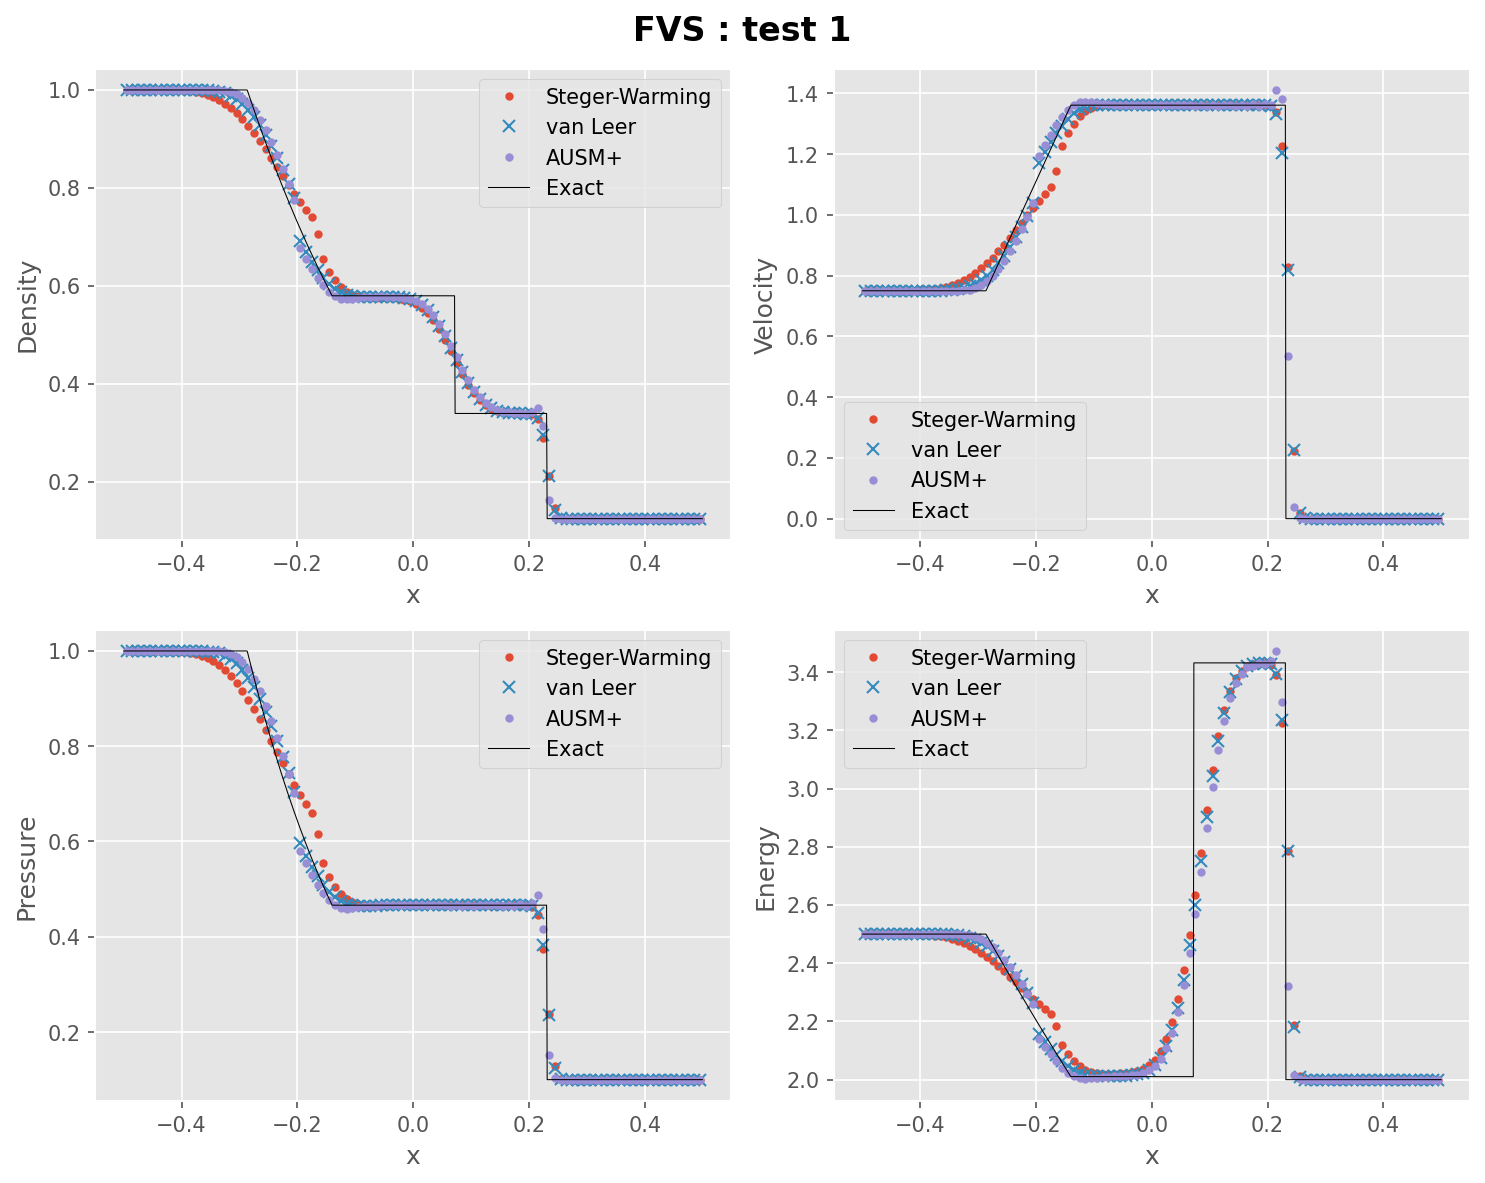

In [7]:
vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}

styles = {
    'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    # 'Roe':            {'linestyle': 'none', 'marker': '.'},
    # 'HLL':            {'marker': 'x'},
    # 'AUSM':       {'linestyle': 'none', 'marker': '.'},
    'AUSM+':       {'linestyle': 'none', 'marker': '.'},
}
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    # plt.figure(figsize=(10, 8))
    plt.subplot(2,2,i)
    
    for name, q in results1.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        # e = p/(gamma - 1) + 0.5 * rho * vel**2
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
            # plt.plot(xc, e, label=name)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
            # plt.plot(xc, q[idx, npad:-npad], label=name)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FVS : test 1', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- HLL은 contact discontinuity의 정보가 불충분
- SL & SR의 정의에 따라 solution의 정확도가 달라짐
- Roe에 entropy fix 적용

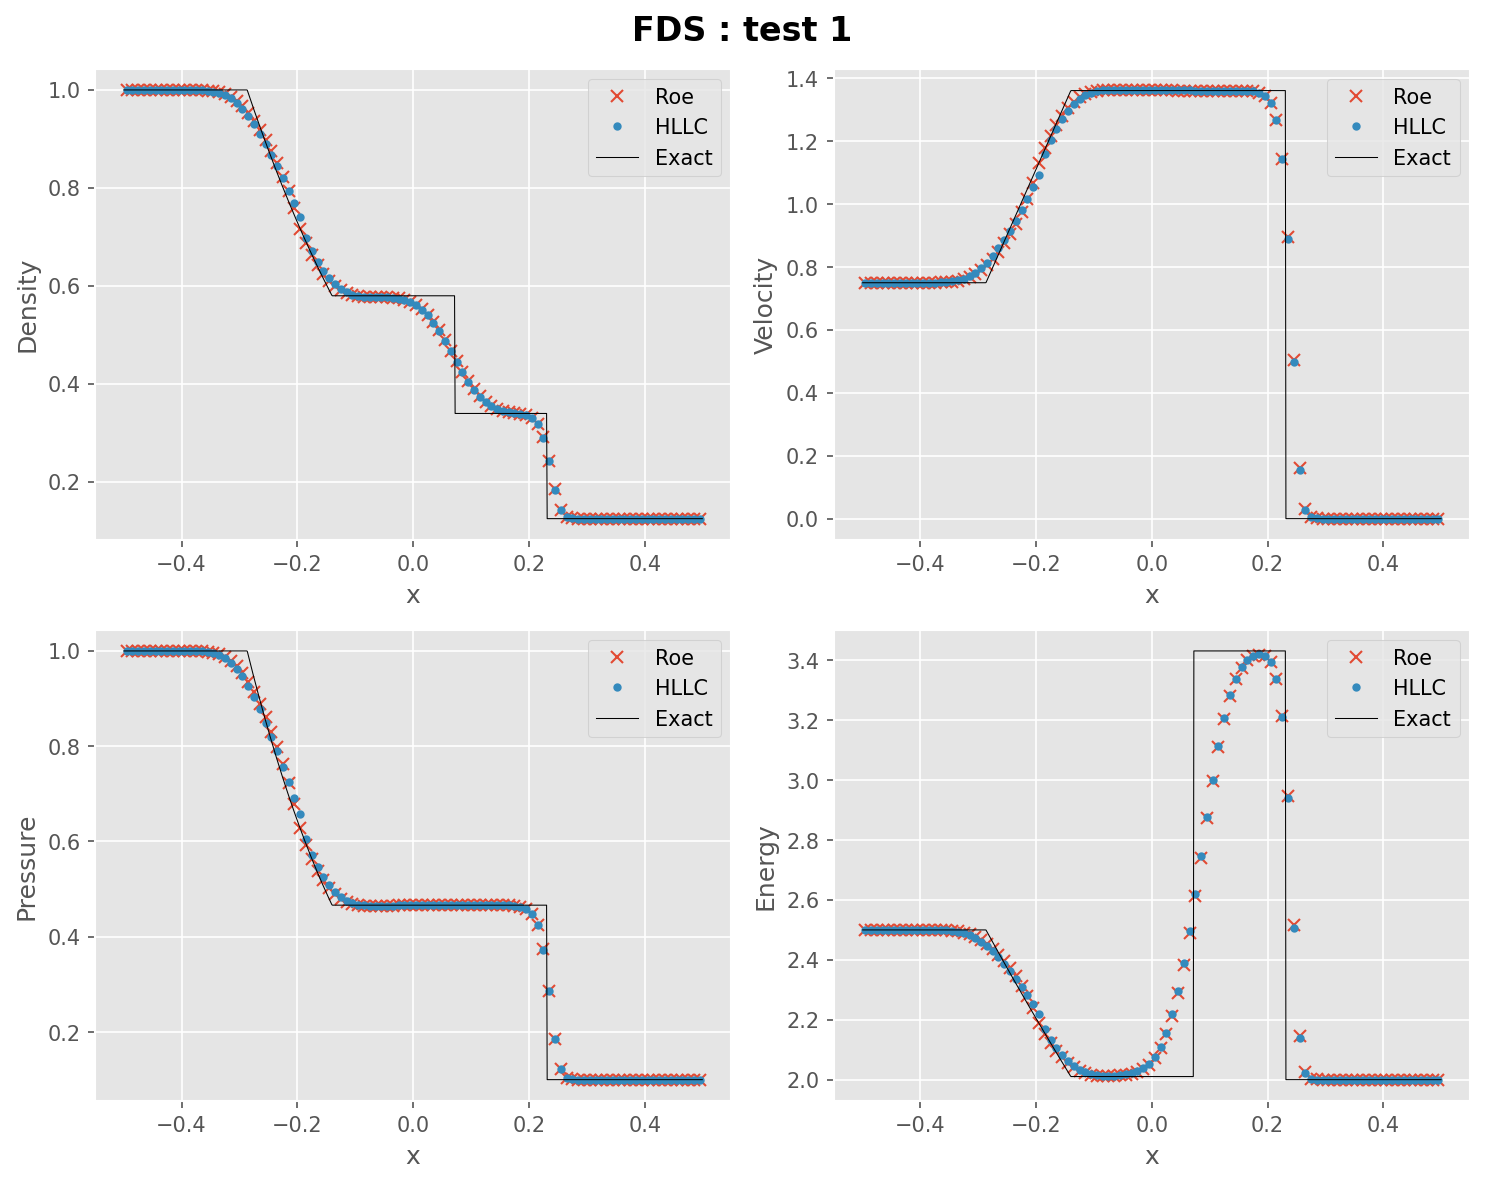

In [8]:
fluxes = {
            # 'Steger-Warming': stegarwarming(gamma, nvars),
#           'Van Leer': vanleer(gamma, nvars),
            'Roe': roe_basic(gamma, nvars),
            # 'HLL': hll(gamma, nvars),
            'HLLC': hllc(gamma, nvars),
            # 'AUSM+': ausmp(gamma, nvars),
}

# CFL 
cfl = 0.5
target_time = 0.2

results_1 = {}

for name, flux in fluxes.items():
    u = run_rsolver(flux, q1, xbk1)
    q = np.empty_like(u)
    to_primitive(u, q)
    results_1[name] = q
    
vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}

styles = {
    # 'Steger-Warming': {'linestyle': '-',  'marker': '.'},
    # 'Van Leer':       {'linestyle': '-', 'marker': 'x'},
    'Roe':             {'linestyle': 'none', 'marker': 'x'},
    # 'HLL':            {'linestyle': 'none','marker': '.'},
    'HLLC':            {'linestyle': 'none','marker': '.'},
    # 'AUSM+':           {'linestyle': 'none', 'marker': '.'},
}
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    # plt.figure(figsize=(10, 8))
    plt.subplot(2,2,i)
    
    for name, q in results_1.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        # e = p/(gamma - 1) + 0.5 * rho * vel**2
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
            # plt.plot(xc, e, label=name)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
            # plt.plot(xc, q[idx, npad:-npad], label=name)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()    

plt.suptitle('FDS : test 1', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Test 2 : Supersonic expansion (123 problem)
- 저밀도 유동에서 기법 성능 평가
- vanleer rarefaction에서 head diffuse

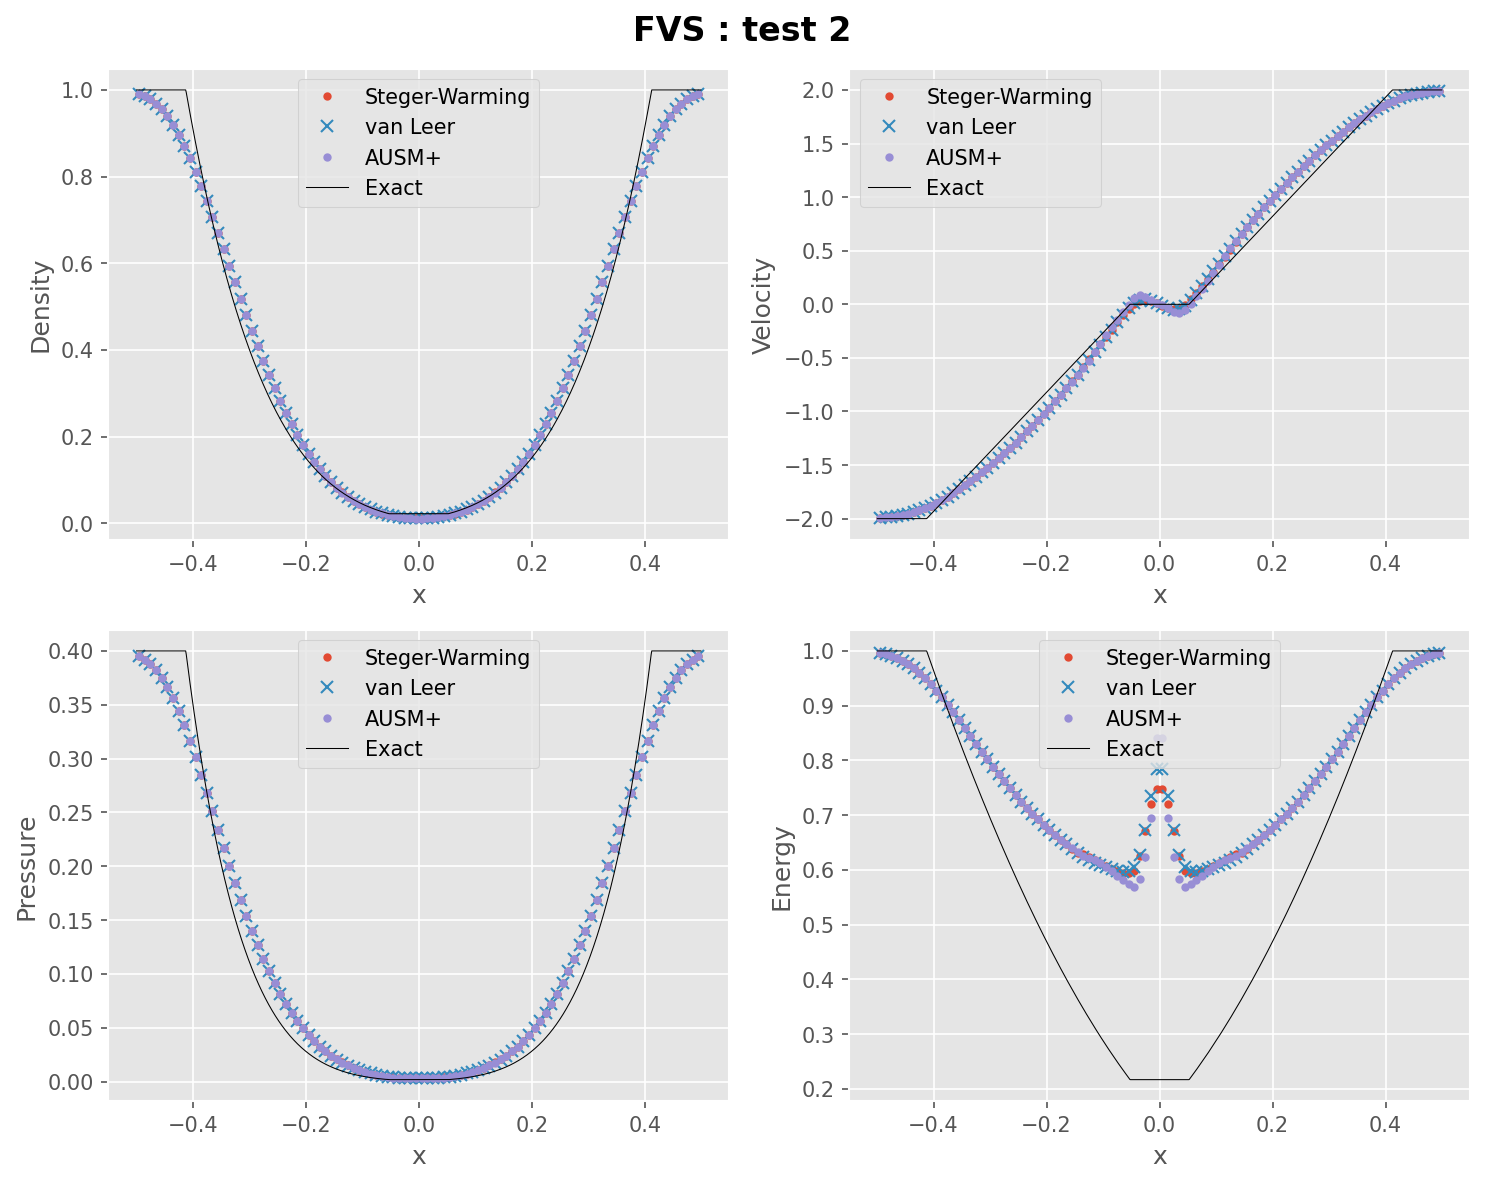

In [9]:
fluxes = {'Steger-Warming': stegarwarming(gamma, nvars),
          'van Leer': vanleer(gamma, nvars),
        #   'Roe': roe(gamma, nvars),
        #   'HLL': hll(gamma, nvars),
         'AUSM+': ausmp(gamma, nvars),
}

x_e, rho_e, u_e, p_e = load_exact(2)
e_e = exact_energy(rho_e, u_e, p_e, gamma)

# CFL 
cfl = 0.5
target_time = 0.15

results2 = {}

for name, flux in fluxes.items():
    u = run_rsolver(flux, q2, xbk2)
    q = np.empty_like(u)
    to_primitive(u, q)
    results2[name] = q

vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}

styles = {
    'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    # 'Roe':            {'linestyle': 'none', 'marker': '.'},
    # 'HLL':            {'marker': 'x'},
    'AUSM+':          {'linestyle': 'none', 'marker': '.'},
}
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    # plt.figure(figsize=(10, 8))
    plt.subplot(2,2,i)
    
    for name, q in results2.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        # e = p/(gamma - 1) + 0.5 * rho * vel**2
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
            # plt.plot(xc, e, label=name)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
            # plt.plot(xc, q[idx, npad:-npad], label=name)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')
        
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FVS : test 2', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- 보존 변수들의 Positivity를 보장하기 위해 Roe + HLLE 인 hybrid 기법을 적용
- Roe 기법 positivity 보장 x

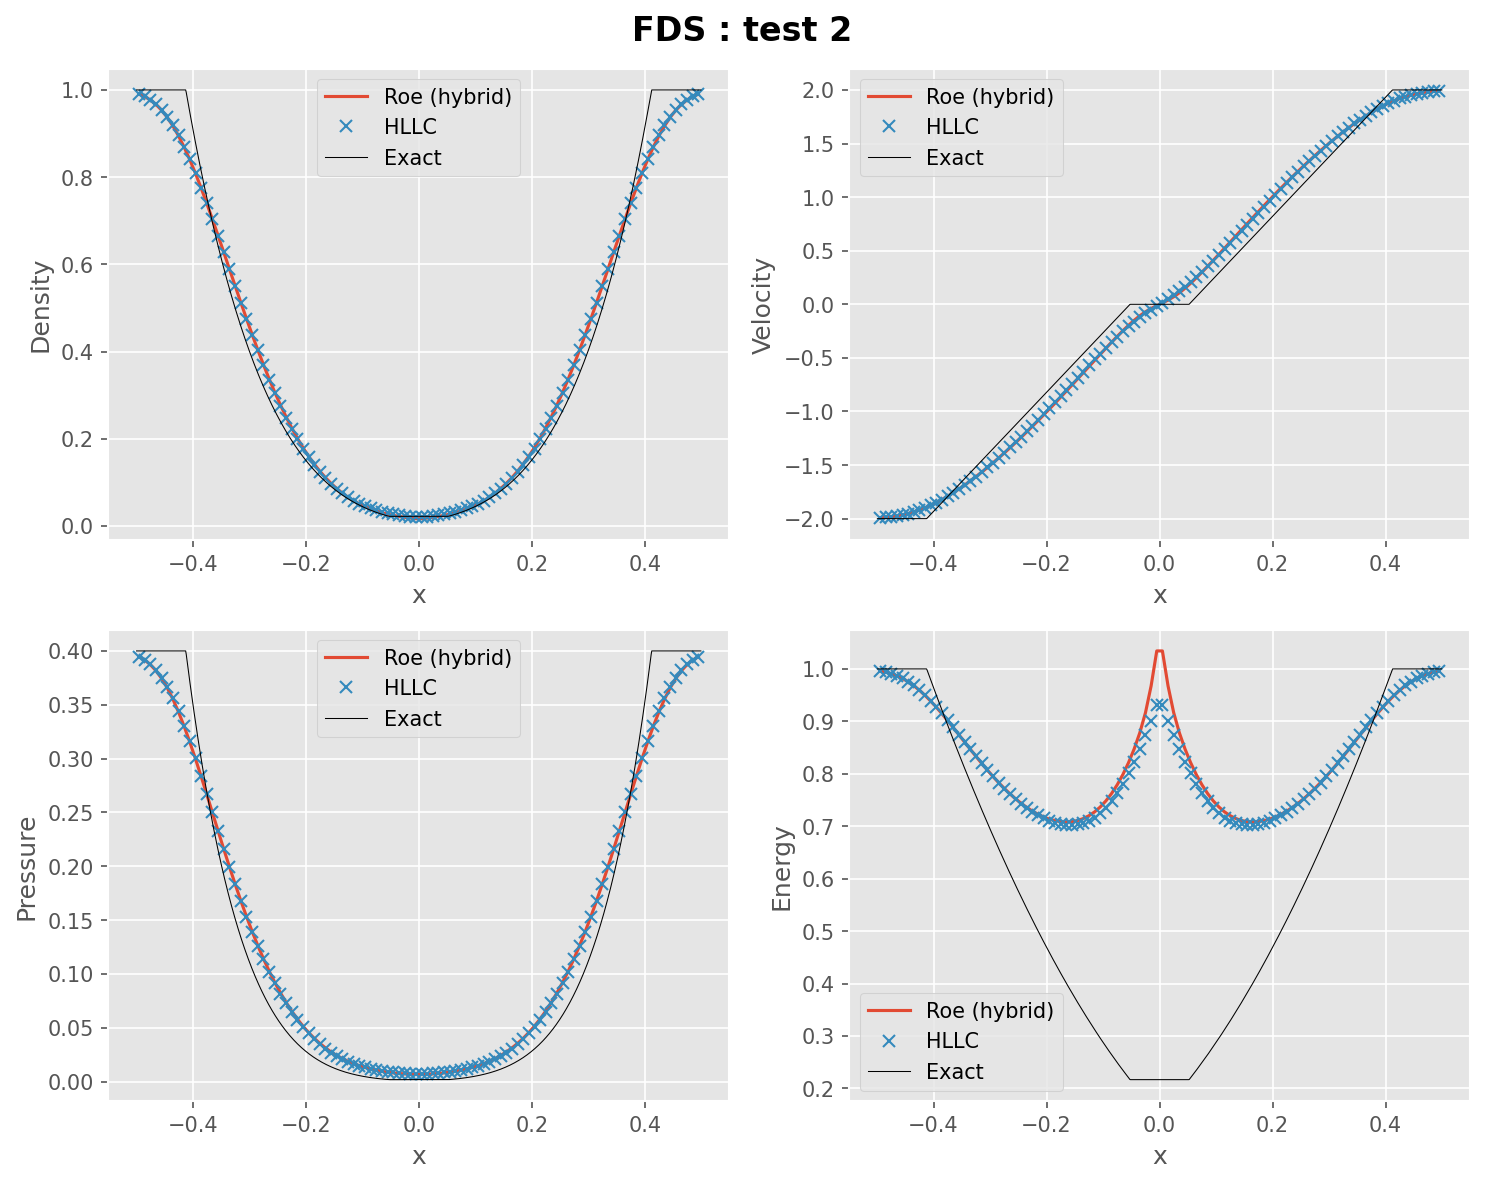

In [13]:
fluxes = {
        #   'Steger-Warming': stegarwarming(gamma, nvars),
        #   'Van Leer': vanleer(gamma, nvars),
          'Roe (hybrid)': roe(gamma, nvars),
          'HLLC': hllc(gamma, nvars),
        #   'AUSM+': ausmp(gamma, nvars),
}

# CFL 
cfl = 0.5
target_time = 0.15

results_2 = {}

x_e, rho_e, u_e, p_e = load_exact(2)
e_e = exact_energy(rho_e, u_e, p_e, gamma)

for name, flux in fluxes.items():
    u = run_rsolver(flux, q2, xbk2)
    q = np.empty_like(u)
    to_primitive(u, q)
    results_2[name] = q

vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}

styles = {
    # 'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    # 'Van Leer':       {'linestyle': 'none', 'marker': 'x'},
    'Roe':            {'linestyle': 'none', 'marker': '.'},
    'HLLC':           {'linestyle': 'none', 'marker': 'x'},
    # 'AUSM+':          {'linestyle': 'none', 'marker': '.'},
}
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    # plt.figure(figsize=(10, 8))
    plt.subplot(2,2,i)
    
    for name, q in results_2.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        # e = p/(gamma - 1) + 0.5 * rho * vel**2
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
            # plt.plot(xc, e, label=name)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
            # plt.plot(xc, q[idx, npad:-npad], label=name)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')
            
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FDS : test 2', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Test 3 : Blast wave problem
- 기법들의 robustness & accuracy 평가
- Stegar-warming : 충격파 뒤 해의 비물리적 저하 (v,p)

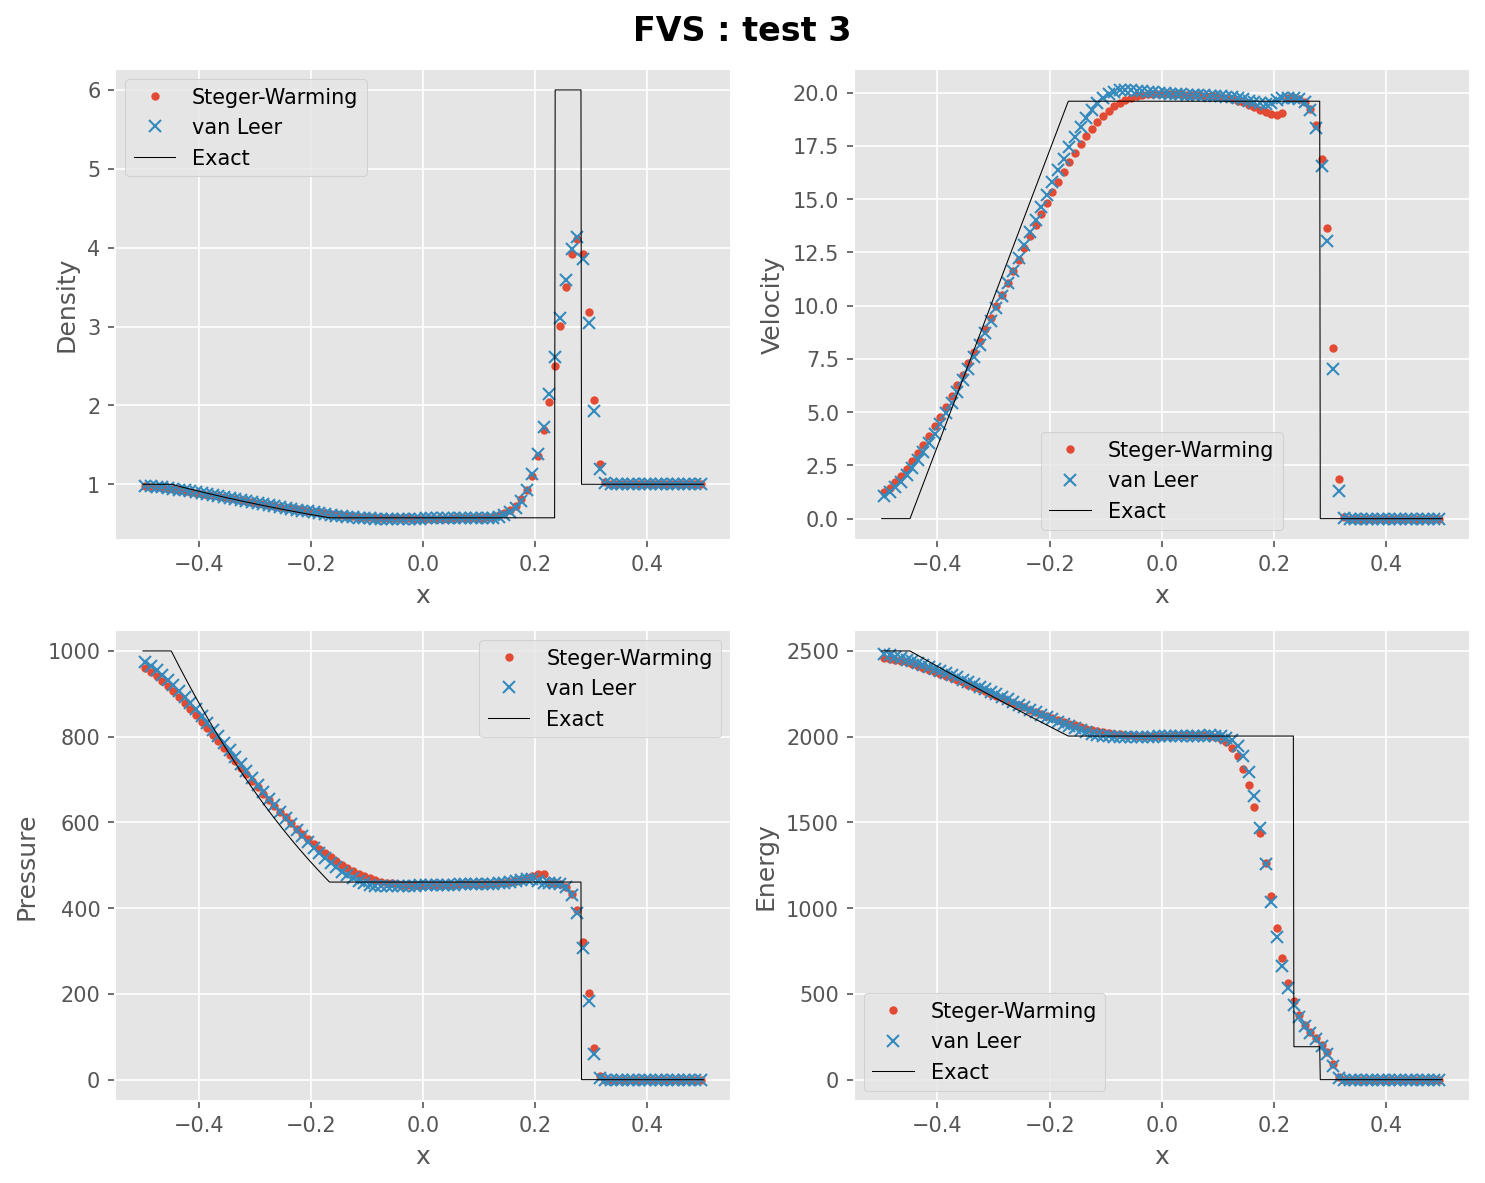

In [ ]:
vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}

fluxes = {
          'Steger-Warming': stegarwarming(gamma, nvars),
          'van Leer': vanleer(gamma, nvars),
        #   'Roe': roe(gamma, nvars),
        #   'HLL': hll(gamma, nvars),
        #  'AUSM+': ausmp(gamma, nvars),
}
results3 = {}

styles = {
    'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    # 'Roe+HLLE':       {'linestyle': '-', 'marker': '.'},
    # 'HLLC':            {'linestyle': '-', 'marker': 'x'},
    # 'AUSM+':       {'linestyle': '-', 'marker': '.'},
}

# CFL 
cfl = 0.6
target_time = 0.012
x_e, rho_e, u_e, p_e = load_exact(3)
e_e = exact_energy(rho_e, u_e, p_e, gamma)

for name, flux in fluxes.items():
    u = run_rsolver(flux, q3, xbk3)
    q = np.empty_like(u)
    to_primitive(u, q)
    results3[name] = q
    
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    plt.subplot(2,2,i)
    
    for name, q in results3.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        # Internal Energy
        e = p/((gamma-1)*rho)
        # Total Energy
        # e = p/(gamma - 1) + 0.5 * rho * vel**2
        
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')   
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FVS : test 3', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

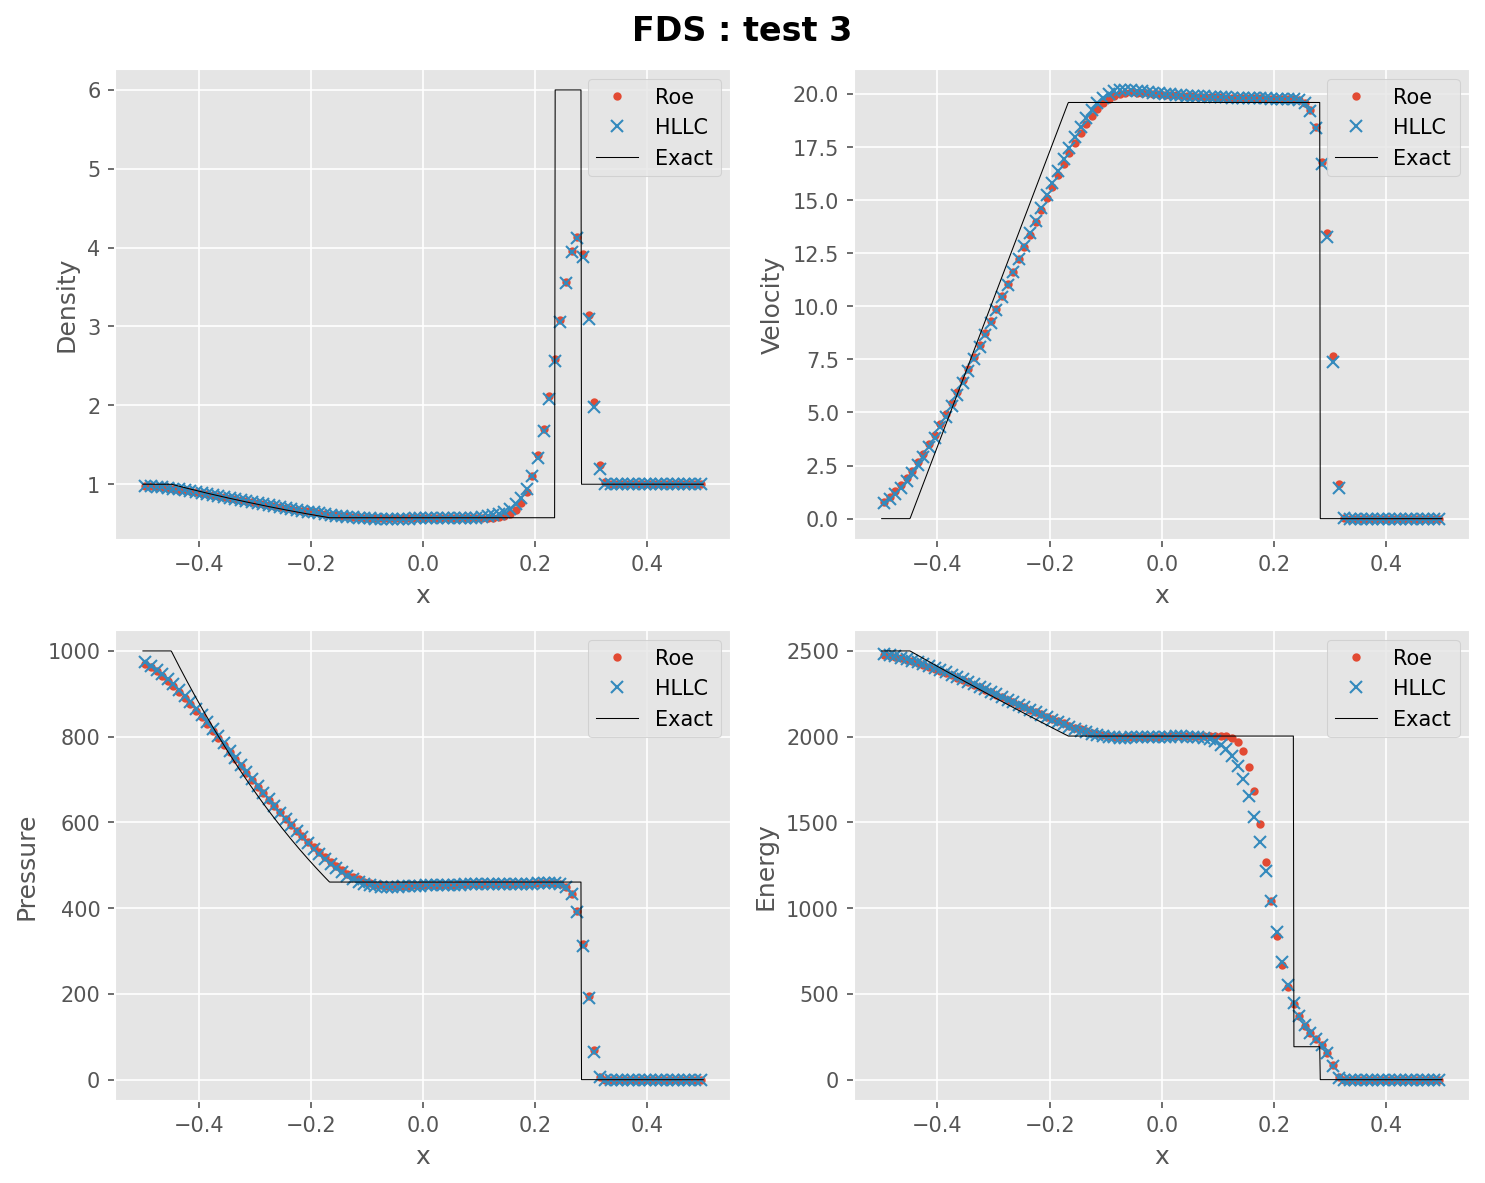

In [ ]:
fluxes = {
        #   'Steger-Warming': stegarwarming(gamma, nvars),
        #   'van Leer': vanleer(gamma, nvars),
          'Roe': roe(gamma, nvars),
          'HLLC': hll(gamma, nvars),
        #  'AUSM+': ausmp(gamma, nvars),
}
results_3 = {}

x_e, rho_e, u_e, p_e = load_exact(3)
e_e = exact_energy(rho_e, u_e, p_e, gamma)

styles = {
    # 'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    # 'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    'Roe':         {'linestyle': 'none', 'marker': '.'},
    'HLLC':        {'linestyle': 'none', 'marker': 'x'},
    # 'AUSM+':       {'linestyle': 'none', 'marker': '.'},
}

# CFL 
cfl = 0.6
target_time = 0.012

for name, flux in fluxes.items():
    u = run_rsolver(flux, q3, xbk3)
    q = np.empty_like(u)
    to_primitive(u, q)
    results_3[name] = q
    
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    plt.subplot(2,2,i)
    
    for name, q in results_3.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        # Internal Energy
        e = p/((gamma-1)*rho)
        # Total Energy
        # e = p/(gamma - 1) + 0.5 * rho * vel**2
        
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')    
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FDS : test 3', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Test 4 : Two strong shock waves traveling towards each other
- 기법들의 robustness 평가
    - 빠른 오른쪽 충격파를 AUSM+가 날카롭게 포착
    - 느린 왼쪽 충격파는 vaneleer보다 퍼짐

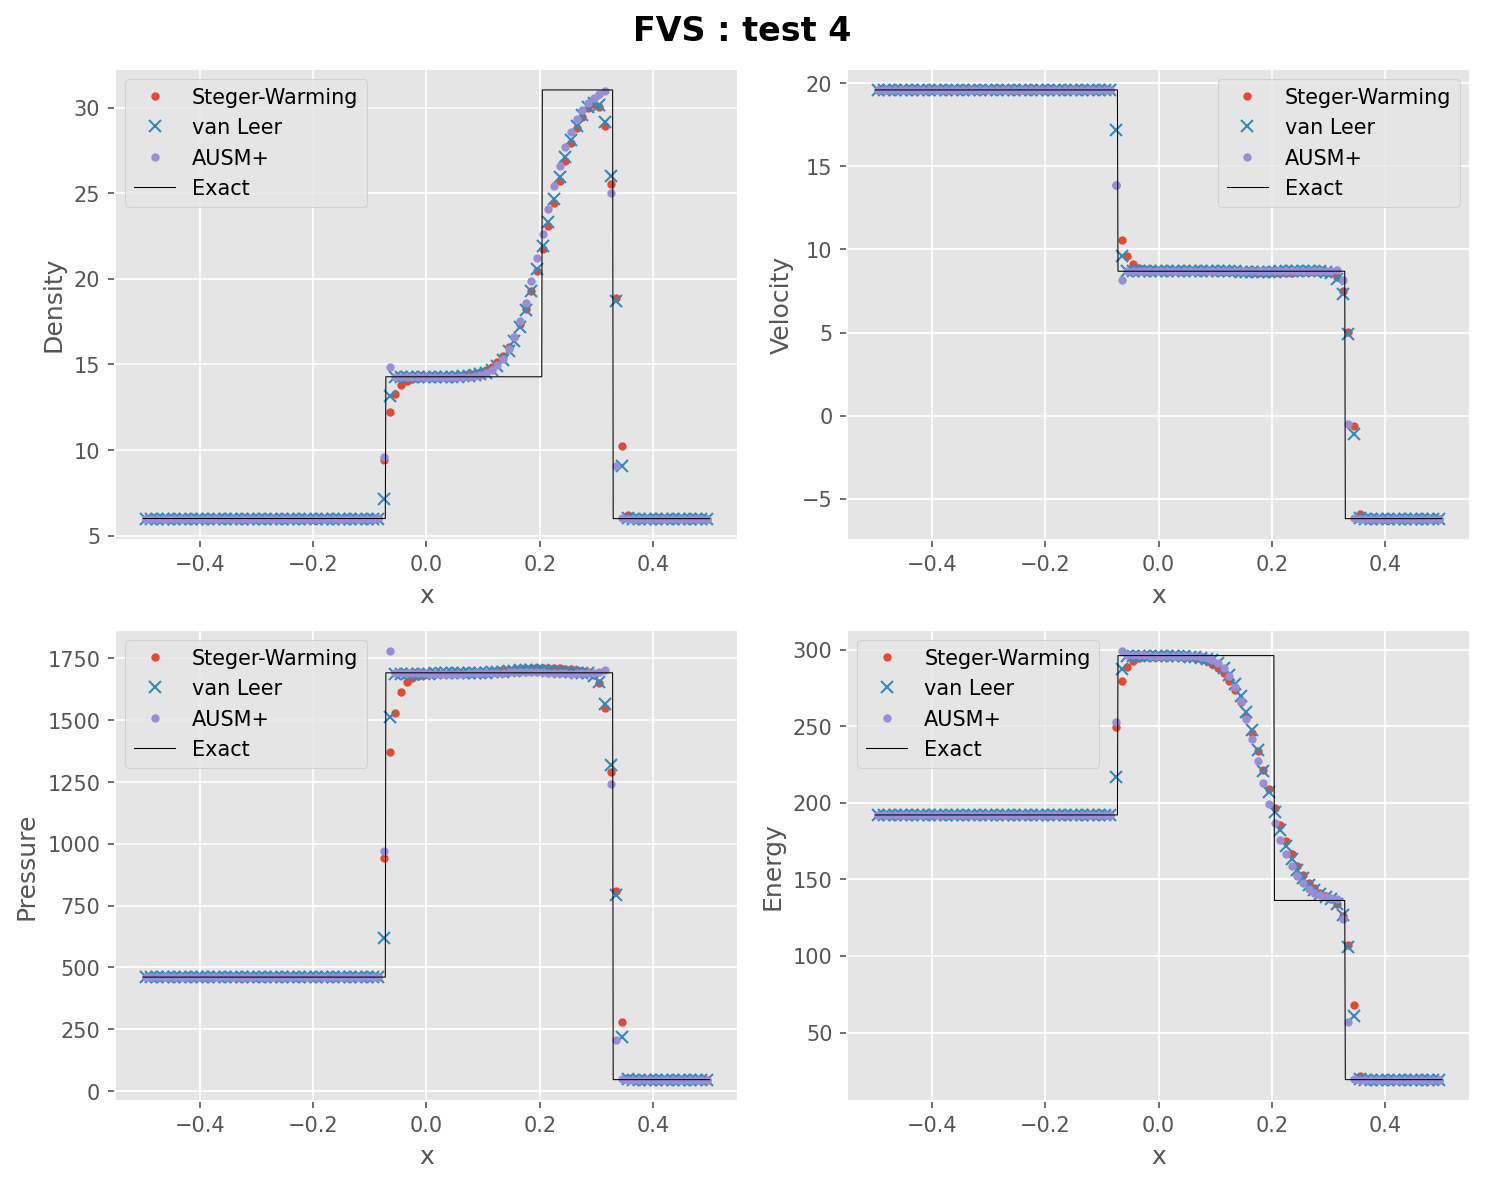

In [ ]:
vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}
fluxes = {
          'Steger-Warming': stegarwarming(gamma, nvars),
          'van Leer': vanleer(gamma, nvars),
        #   'Roe': roe(gamma, nvars),
        #   'HLL': hll(gamma, nvars),
         'AUSM+': ausmp(gamma, nvars),
}
results_4 = {}
x_e, rho_e, u_e, p_e = load_exact(4)
e_e = exact_energy(rho_e, u_e, p_e, gamma)
styles = {
    'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    # 'Roe+HLLE':       {'linestyle': '-', 'marker': '.'},
    # 'HLLC':            {'linestyle': '-', 'marker': 'x'},
    'AUSM+':       {'linestyle': 'none', 'marker': '.'},
}

# CFL 
cfl = 0.8
target_time = 0.035

for name, flux in fluxes.items():
    u = run_rsolver(flux, q4, xbk4)
    q = np.empty_like(u)
    to_primitive(u, q)
    results_4[name] = q
    
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    plt.subplot(2,2,i)
    
    for name, q in results_4.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')    
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FVS : test 4', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

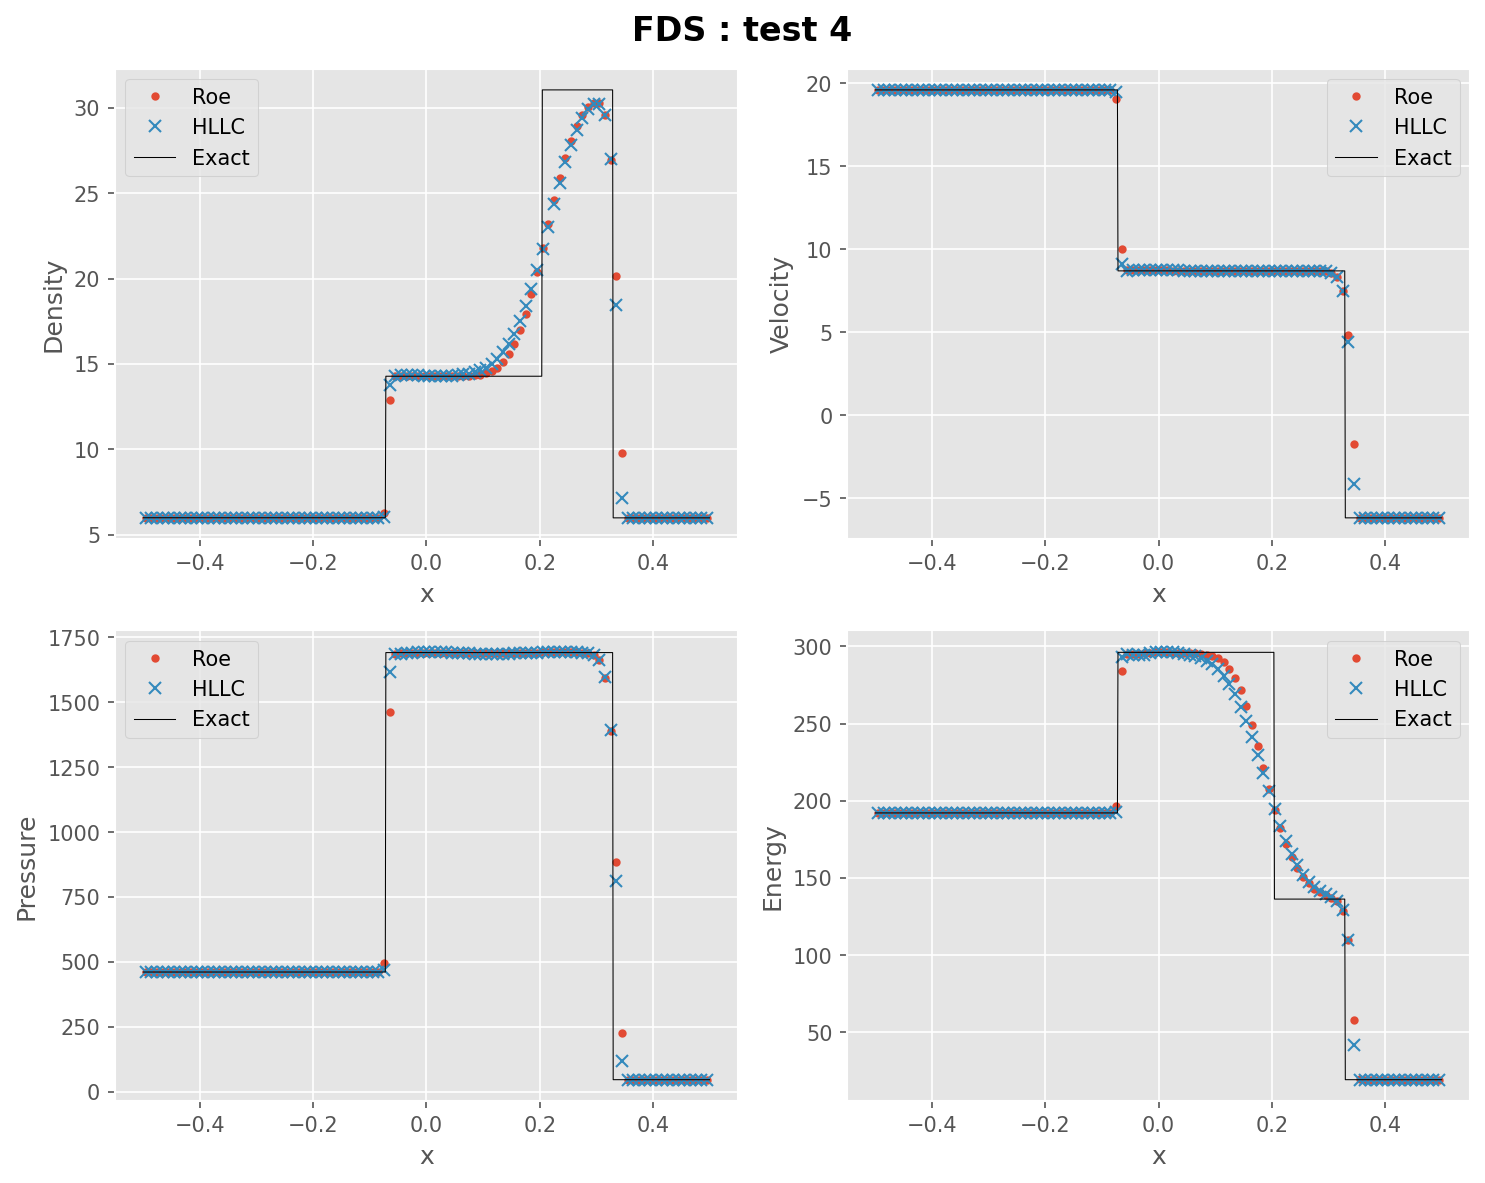

In [ ]:
vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}
fluxes = {
        #   'Steger-Warming': stegarwarming(gamma, nvars),
        #   'van Leer': vanleer(gamma, nvars),
          'Roe': roe_basic(gamma, nvars),
          'HLLC': hll(gamma, nvars),
        #   'AUSM+': ausmp(gamma, nvars),
}
results4 = {}
x_e, rho_e, u_e, p_e = load_exact(4)
e_e = exact_energy(rho_e, u_e, p_e, gamma)
styles = {
    # 'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    # 'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    'Roe':             {'linestyle': 'none', 'marker': '.'},
    'HLLC':            {'linestyle': 'none', 'marker': 'x'},
    # 'AUSM+':           {'linestyle': 'none', 'marker': '.'},
}

# CFL 
cfl = 0.8
target_time = 0.035

for name, flux in fluxes.items():
    u = run_rsolver(flux, q4, xbk4)
    q = np.empty_like(u)
    to_primitive(u, q)
    results4[name] = q
    
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    plt.subplot(2,2,i)
    
    for name, q in results4.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')    
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FDS : test 4', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Test 5 : Slowly-moving contact discontinuities
- AUSM+ : more accuracy but oscillation

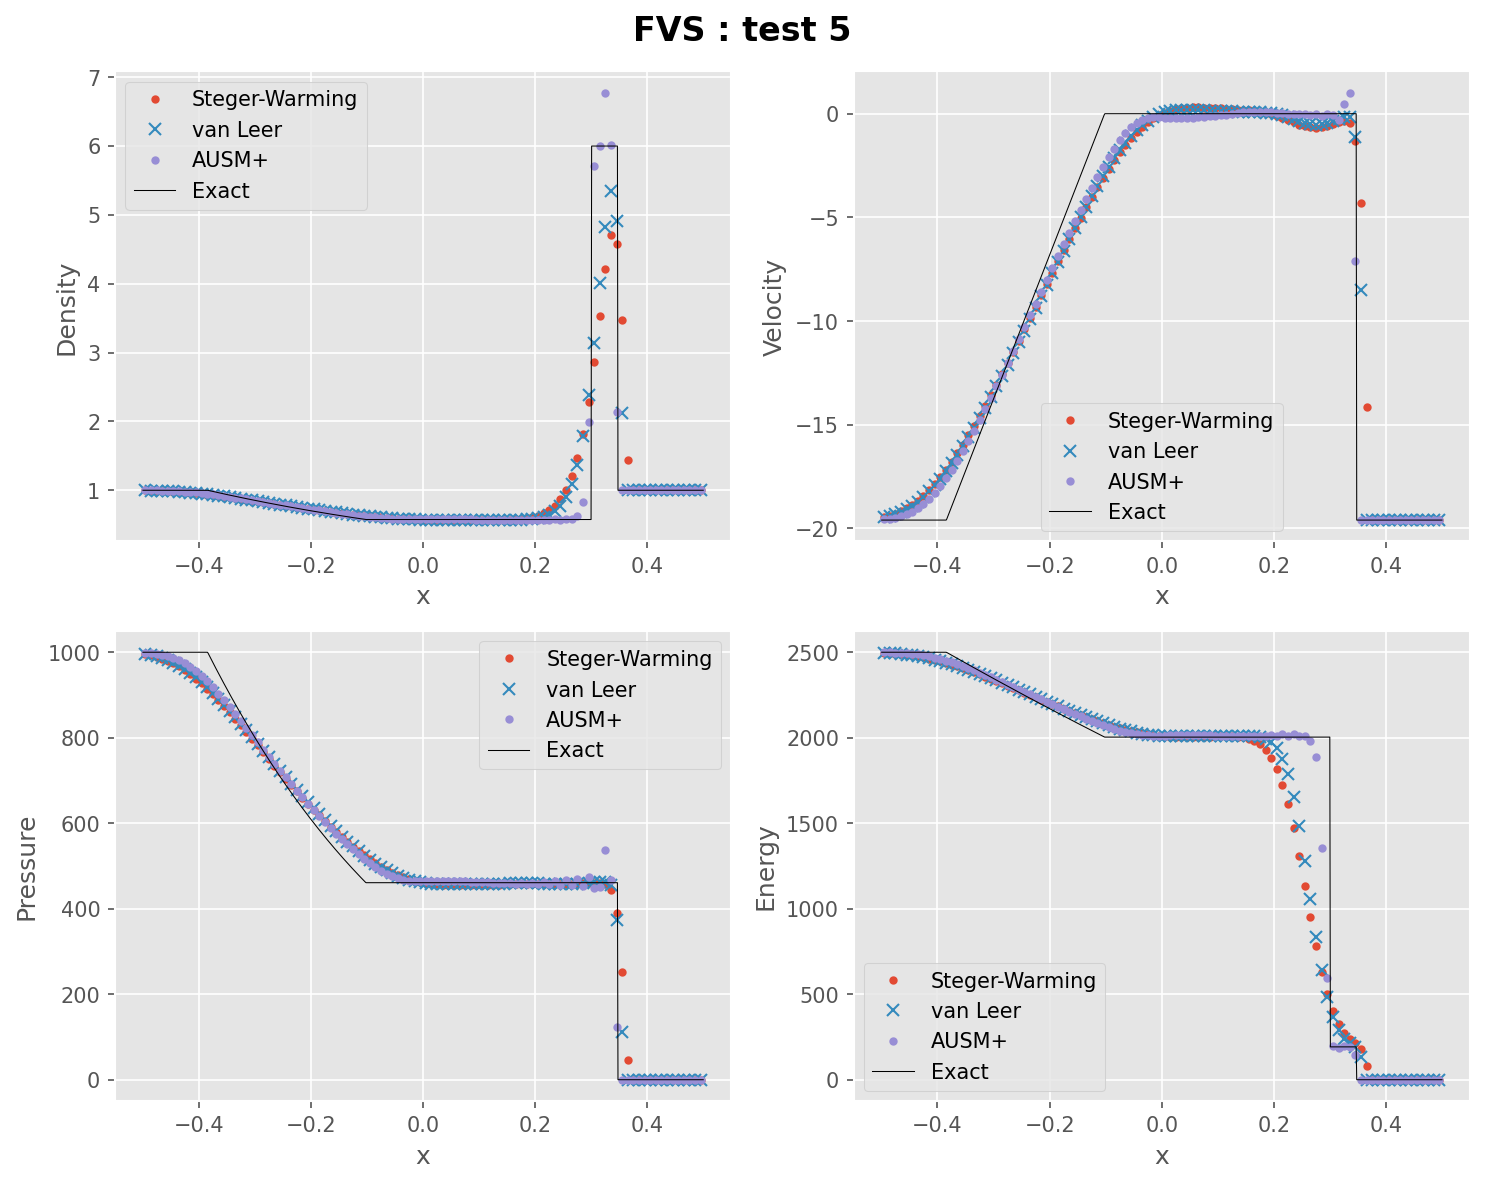

In [ ]:
vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}
fluxes = {
          'Steger-Warming': stegarwarming(gamma, nvars),
          'van Leer': vanleer(gamma, nvars),
        #   'Roe': roe(gamma, nvars),
        #   'HLL': hll(gamma, nvars),
         'AUSM+': ausmp(gamma, nvars),
}
results_5 = {}

styles = {
    'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    # 'Roe+HLLE':       {'linestyle': '-', 'marker': '.'},
    # 'HLLC':            {'linestyle': '-', 'marker': 'x'},
    'AUSM+':       {'linestyle': 'none', 'marker': '.'},
}

# CFL 
cfl = 0.6
target_time = 0.012

x_e, rho_e, u_e, p_e = load_exact(5)
e_e = exact_energy(rho_e, u_e, p_e, gamma)

for name, flux in fluxes.items():
    u = run_rsolver(flux, q5, xbk5)
    q = np.empty_like(u)
    to_primitive(u, q)
    results_5[name] = q
    
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    plt.subplot(2,2,i)
    
    for name, q in results_5.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')    
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FVS : test 5', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

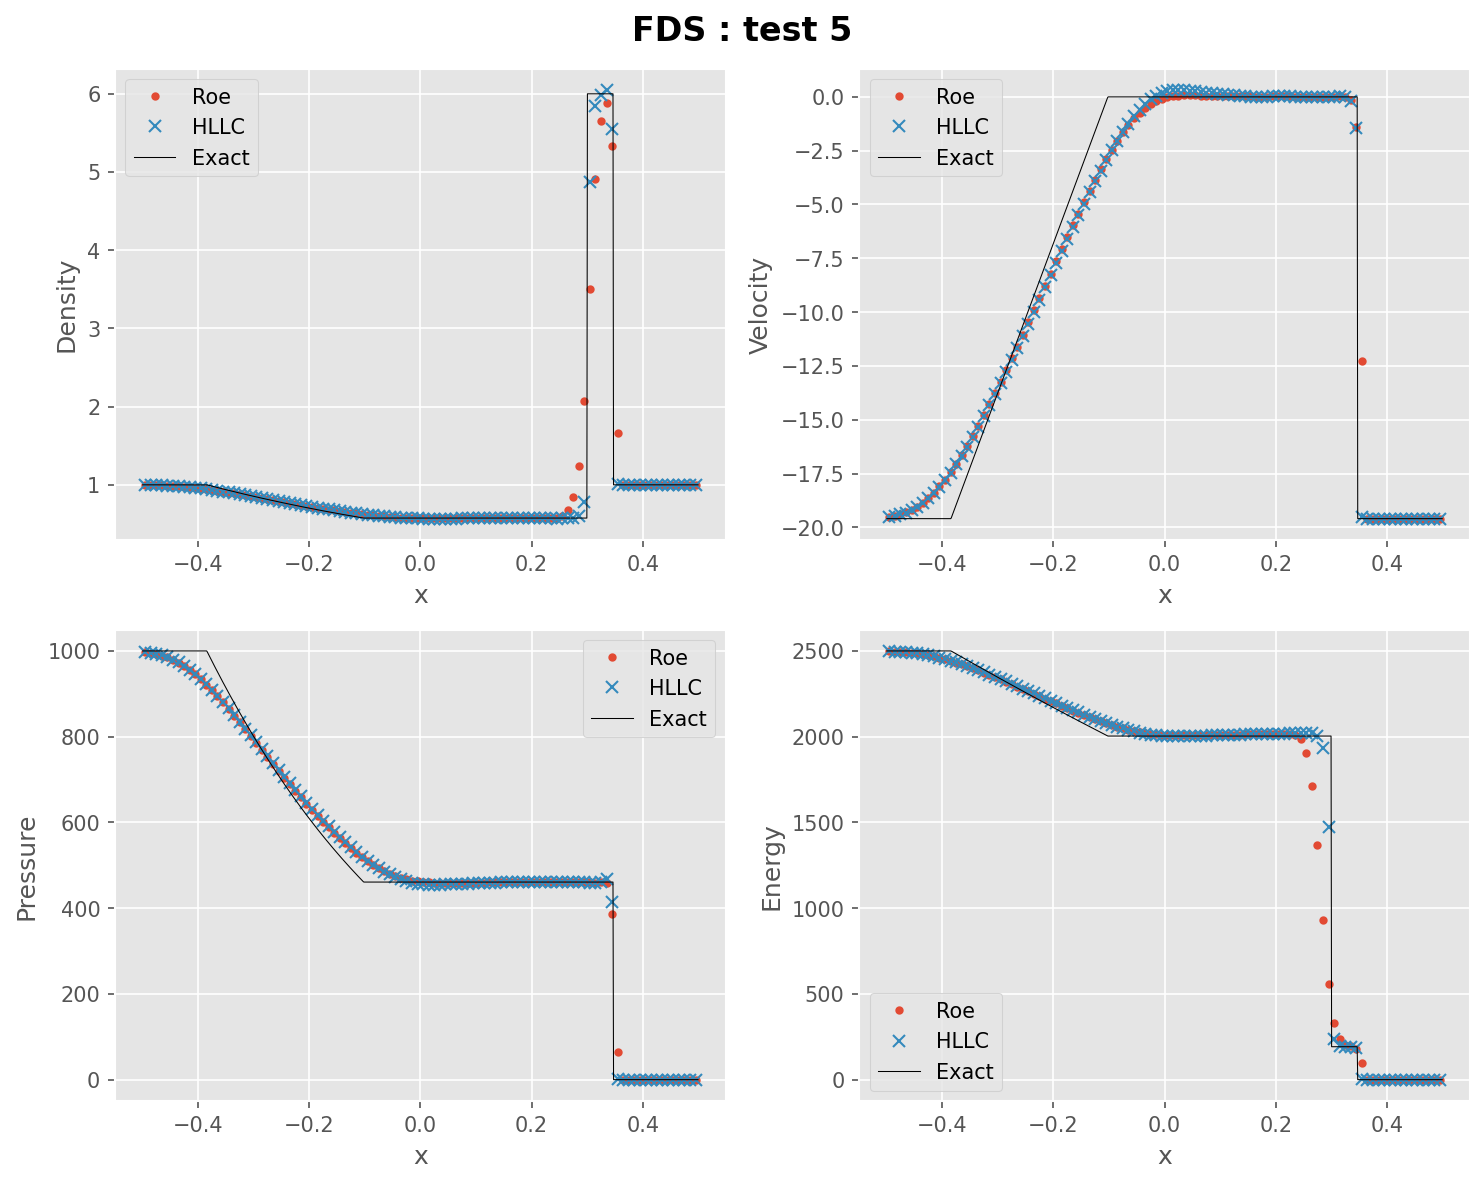

In [ ]:
vars_idx = {
    'Density': 0,
    'Velocity': 1,
    'Pressure': 2,
    'Energy' : 3,
}
fluxes = {
        #   'Steger-Warming': stegarwarming(gamma, nvars),
        #   'van Leer': vanleer(gamma, nvars),
          'Roe': roe_basic(gamma, nvars),
          'HLLC': hllc(gamma, nvars),
        #   'AUSM+': ausmp(gamma, nvars),
}
results_5 = {}
x_e, rho_e, u_e, p_e = load_exact(5)
e_e = exact_energy(rho_e, u_e, p_e, gamma)
styles = {
    # 'Steger-Warming': {'linestyle': 'none',  'marker': '.'},
    # 'van Leer':       {'linestyle': 'none', 'marker': 'x'},
    'Roe':             {'linestyle': 'none', 'marker': '.'},
    'HLLC':            {'linestyle': 'none', 'marker': 'x'},
    # 'AUSM+':           {'linestyle': 'none', 'marker': '.'},
}

# CFL 
cfl = 0.6
target_time = 0.012

for name, flux in fluxes.items():
    u = run_rsolver(flux, q5, xbk5)
    q = np.empty_like(u)
    to_primitive(u, q)
    results_5[name] = q
    
plt.figure(figsize=(10, 8))

for i, (var, idx) in enumerate(vars_idx.items(), 1):
    plt.subplot(2,2,i)
    
    for name, q in results_5.items():
        rho = q[0, npad:-npad]
        vel = q[1, npad:-npad]
        p = q[2, npad:-npad]
        e = p/((gamma-1)*rho)
        
        style = styles.get(name, {})

        if var == 'Energy':
            plt.plot(xc, e, label=name, **style)
        else:
            plt.plot(xc, q[idx, npad:-npad], label=name, **style)
    if var == 'Density':
        plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Velocity':
        plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Pressure':
        plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
    elif var == 'Energy':
        plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')    
    plt.xlabel('x')
    plt.ylabel(var)
    plt.legend()

plt.suptitle('FDS : test 5', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from solvers.rhside import make_rhside_muscl
from solvers.limiter import get_limiter
from solvers.tvdrk3 import make_tvdrk3
from solvers.rsolver.get_rsolver import get_rsolver

In [ ]:
def make_rhside_muscl(nfx, dx, fluxn, bcn='zero', limitern='none', nvars=3, gamma=1.4, npad=1):    
    """
    Kernal generator for right hand side (MUSCL version)
    
    Parameters
    ----------
    nfx : integer
        격자 개수
    dx : float
        격자 간격
    fluxn : string
        근사 리만 해석자 함수 이름
    bcn : string
        경계조건 함수 이름
    limitern : string
        Limiter 이름
    nvars : integer
        벡터 크기 (기본값: 3)
    gamma : float
        비열비 (기본값: 1.4)
    npad : integer
        경계를 위한 padding 개수 (기본값: 1)
    """
    # Generate bc zero (TODO)
    bc = make_bc_zero(nfx, npad)
    
    # Generate flux and phi functions
    flux = get_rsolver(fluxn, gamma, nvars)
    phi = get_limiter(limitern)

    def _run(u, du, f):
        # Allocate local static array
        fn = np.empty(nvars)
        ul, ur = np.empty(nvars), np.empty(nvars)
        # Compute BC
        bc(u)

        # Compute flux at each face
        for i in range(nfx+1):
            # left index i at the face i+1/2
            idx = i + npad -1
            
            if (i == 0) or (i == nfx):
                for j in range(nvars):
                    ul[j] = u[j, idx]
                    ur[j] = u[j, idx+1]
            else:                
                for j in range(nvars):
                    dp = u[j, idx+1] - u[j, idx]
                    dm = u[j, idx] - u[j, idx-1]

                    sl = phi(dp, dm) * dm
                    ul[j] = u[j, idx] + 0.5 * sl

                    dp = u[j, idx+2] - u[j, idx+1]
                    dm = u[j, idx+1] - u[j, idx]

                    sr = phi(dp, dm) * dm
                    ur[j] = u[j, idx+1] - 0.5*sr
            
            flux(ul, ur, fn)
            f[:, i] = fn

        # negative derivative of flux at each cell
        for i in range(nfx):        
            du[:, npad+i] = -(f[:, i+1] - f[:, i])/dx
            
    return _run

In [ ]:
# Constants
gamma = 1.4
nvars = 3

# 격자 개수
nfx = 100
npad = 1

# CFL 수
cfl = 0.9

# Schemes
flux = 'roe'
limiter = 'minmod'

# Initial conditions (Primitive)
ql = (1.0, 0.0, 1.0)
qr = (0.125, 0.0, 0.1)
xbk = 0.0
target_time = 0.2

# Uniform 1d grid
xc, dx = make_uniform_grid1d(nfx, (-0.5, 0.5))

# Array
u = np.empty((nvars,nfx+2*npad))

bc = make_bc_zero(nfx, npad)

rhside = make_rhside_muscl(
    nfx, dx,
    flux,
    bc,          # ← 문자열 말고 함수 넣기
    limiter,
    nvars, gamma, npad
)

# Generate kernels
rhside = make_rhside_muscl(nfx, dx, flux, bc, limiter, nvars, gamma, npad)
step = make_tvdrk3(nfx, rhside, nvars, npad)
timestep = make_timestep(nfx, dx, cfl, gamma, nvars, npad)

# Initialize
ul = np.empty(nvars)
ur = np.empty(nvars)

to_conservative(ql, ul)
to_conservative(qr, ur)

for i, xi in enumerate(xc):
    if xi < xbk:
        u[:, i+npad] = ul
    else:
        u[:, i+npad] = ur
        
# Main Loop        
t = 0
n = 0
while abs(t - target_time) > np.finfo(1.0).eps:
    # Compute time step
    dt = min(timestep(u), target_time - t)
    
    # Step
    step(dt, u)
    t += dt
    n += 1

print("{} iterations until t={:.3f}".format(n, t))

Riemann Solver : roe
Minmod limiter
Riemann Solver : roe
Minmod limiter
48 iterations until t=0.200


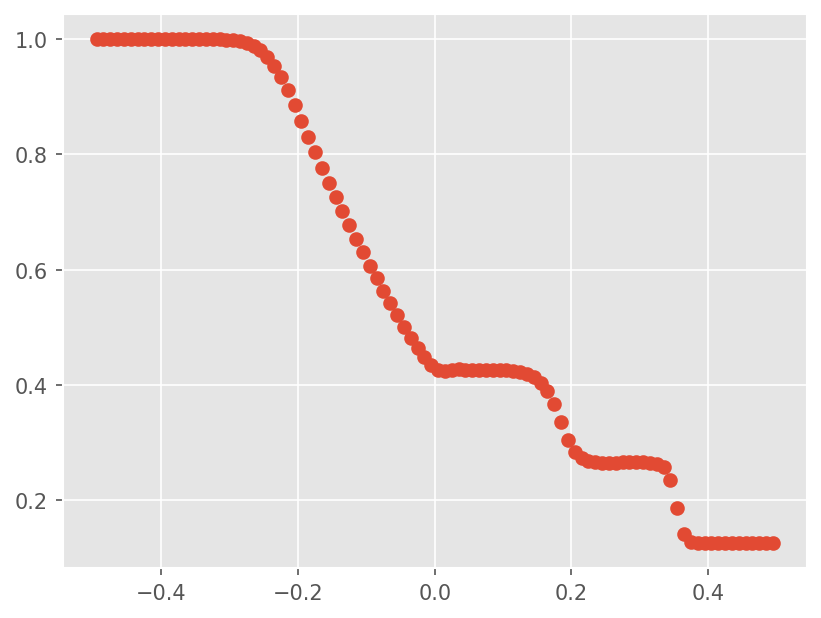

In [ ]:
# 가시화
q = np.empty_like(u)
to_primitive(u, q)

fig, ax = plt.subplots()
ax.plot(xc, q[0, npad:-npad], marker='o', linestyle='none')

In [ ]:
def run_muscl_solver(flux_name, limiter_name, q_num, xbk):
    # Array
    u = np.empty((nvars, nfx + 2*npad))

    # kernels
    bc = make_bc_zero(nfx, npad)

    # 🔥 핵심: 문자열 기반으로 통일
    rhside = make_rhside_muscl(
        nfx, dx,
        flux_name,     # 문자열 ('roe', 'ausmp')
        bc,
        limiter_name,  # 문자열 ('minmod', ...)
        nvars, gamma, npad
    )

    step = make_tvdrk3(nfx, rhside, nvars, npad)
    timestep = make_timestep(nfx, dx, cfl, gamma, nvars, npad)

    # initialize
    ul = np.empty(nvars)
    ur = np.empty(nvars)

    to_conservative(q_num[0], ul)
    to_conservative(q_num[1], ur)

    for i, xi in enumerate(xc):
        if xi < xbk:
            u[:, i+npad] = ul
        else:
            u[:, i+npad] = ur

    # time loop
    t = 0
    n = 0
    while abs(t - target_time) > np.finfo(1.0).eps:
        dt = min(timestep(u), target_time - t)
        step(dt, u)
        t += dt
        n += 1

    print(f"{flux_name}-{limiter_name}: {n} iterations")

    return u

In [ ]:
flux_list = ['roe', 'ausmp']
limiter_list = ['minmod']
# limiter_list = ['minmod', 'van_leer', 'superbee']

results = {}

for flux_name in flux_list:
    for limiter_name in limiter_list:
        key = f"{flux_name}-{limiter_name}"
        u = run_muscl_solver(flux_name, limiter_name, (ql, qr), xbk)

        q = np.empty_like(u)
        to_primitive(u, q)

        results[key] = q

Riemann Solver : roe
Minmod limiter
roe-minmod: 48 iterations
Riemann Solver : ausmp
Minmod limiter
ausmp-minmod: 48 iterations


#### Test 1 : Modified SOD shocktube Problem
- 기법들의 Entropy satisfaction을 평가 
- 안정한 포착을 위해 minmod, vanLeer limiter 적용

In [ ]:
def plot_muscl_results(results, xc, npad, gamma):
    vars_idx = {
        'Density': 0,
        'Velocity': 1,
        'Pressure': 2,
        'Energy': 3
    }

    plt.figure(figsize=(12, 10))
    x_e, rho_e, u_e, p_e = load_exact(4)
    e_e = exact_energy(rho_e, u_e, p_e, gamma)
    for i, (var, idx) in enumerate(vars_idx.items(), 1):
        plt.subplot(2, 2, i)

        for name, q in results.items():
            rho = q[0, npad:-npad]
            vel = q[1, npad:-npad]
            p   = q[2, npad:-npad]

            # Total Energy
            E = p/((gamma-1)*rho)

            if var == 'Energy':
                plt.plot(xc, E, marker='.', linestyle='None', label=name)
            else:
                plt.plot(xc, q[idx, npad:-npad], marker='.', linestyle='None', label=name)
        if var == 'Density':
            plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
        elif var == 'Velocity':
            plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
        elif var == 'Pressure':
            plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
        elif var == 'Energy':
            plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')
        plt.xlabel('x')
        plt.ylabel(var)
        plt.legend(fontsize=12)

    plt.suptitle('Test 4 : MUSCL ', fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()

#### Test 4 : Two strong shock waves traveling towards each other
- 기법들의 robustness 평가

Riemann Solver : roe
Minmod limiter
roe-minmod: 132 iterations
Riemann Solver : ausmp
Minmod limiter
ausmp-minmod: 132 iterations


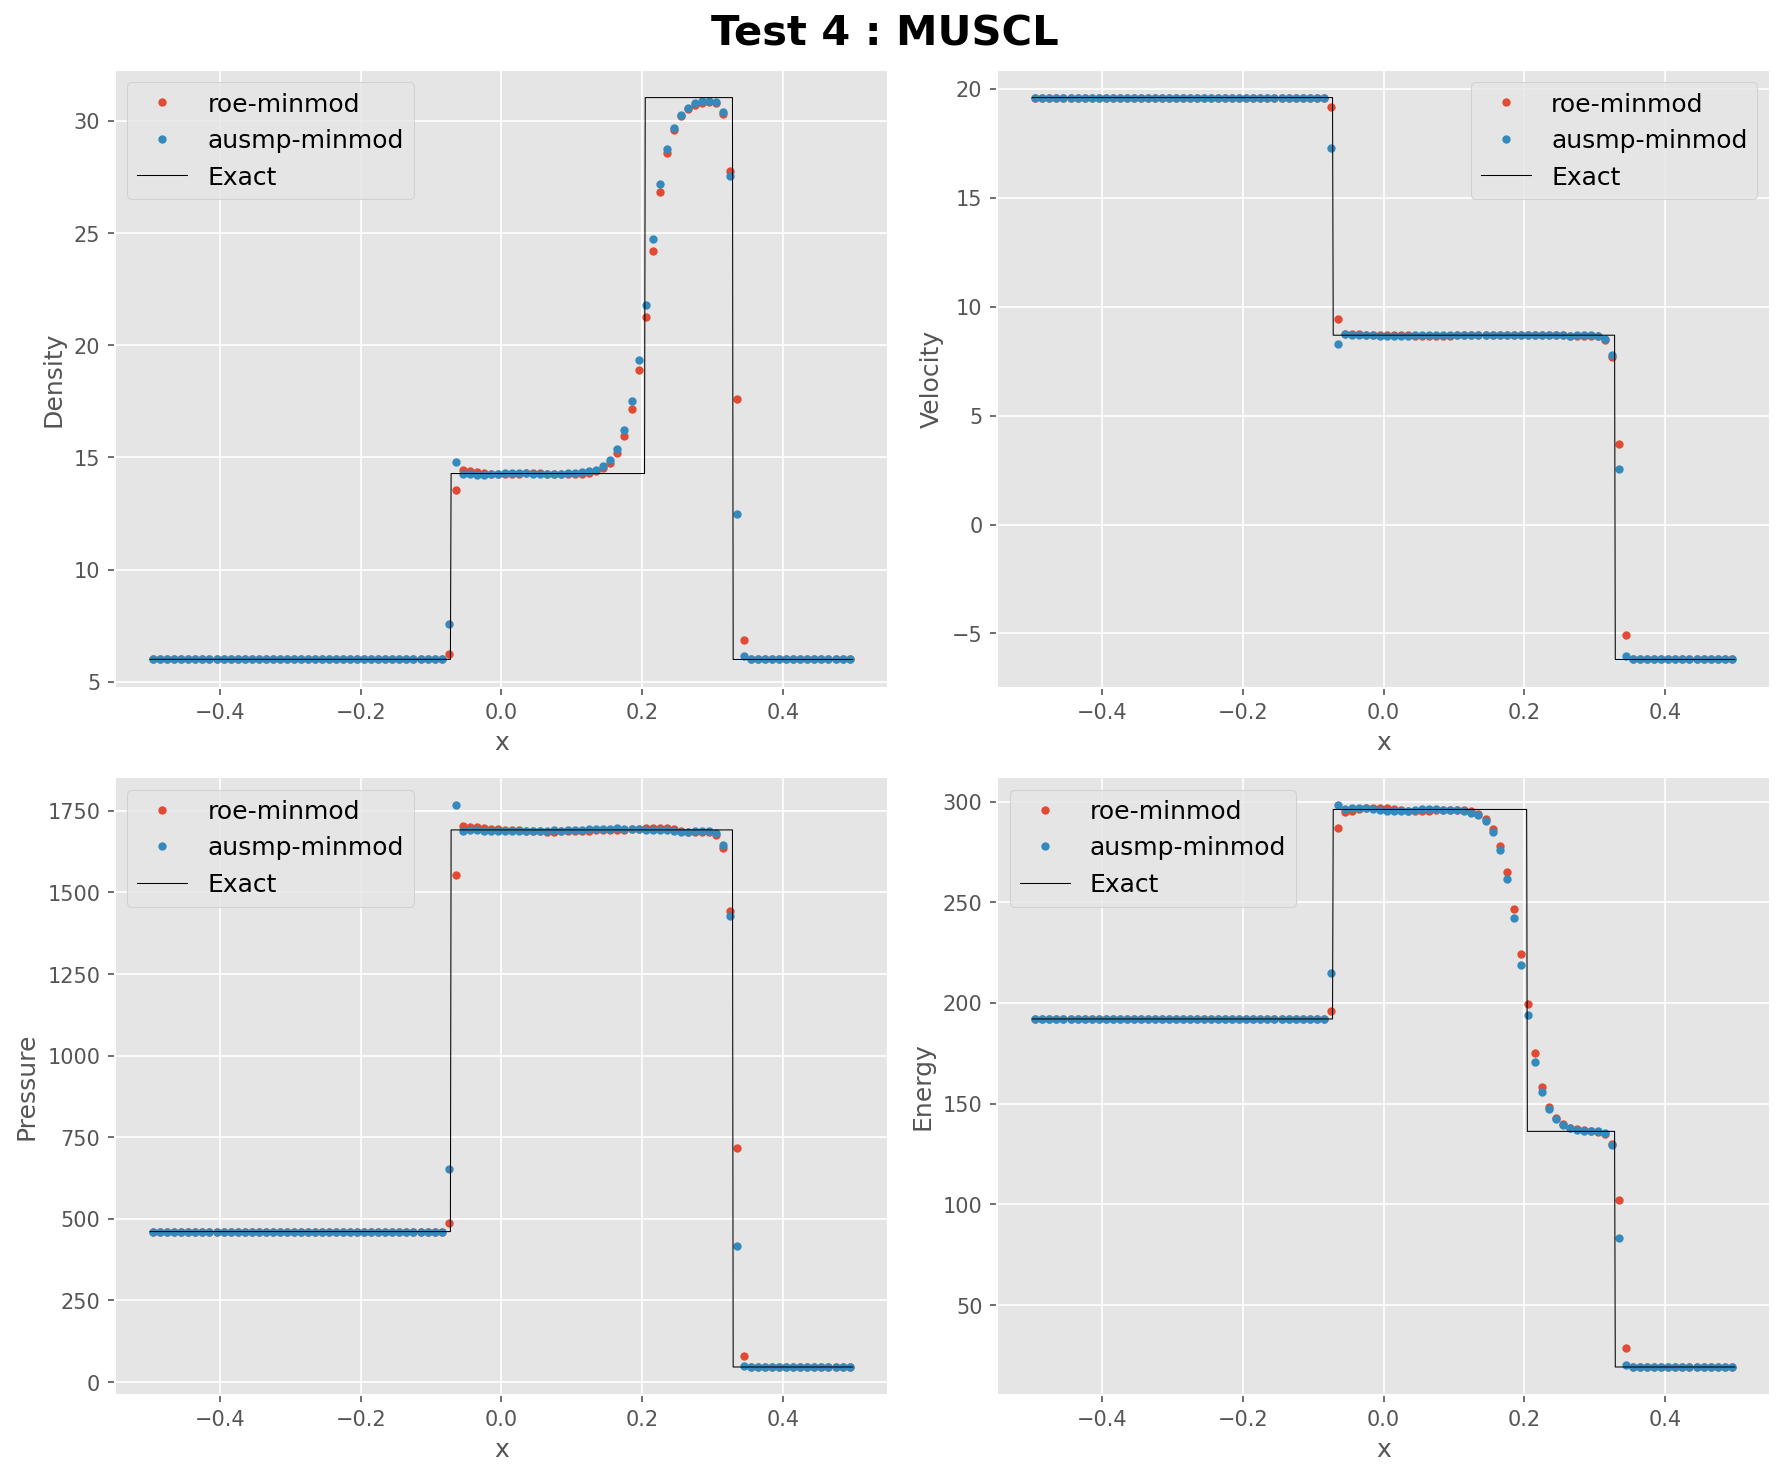

In [ ]:
flux_list = ['roe', 'ausmp']
limiter_list = ['minmod']
# limiter_list = ['minmod', 'van_leer', 'superbee']

results30 = {}

# CFL 
cfl = 0.8
target_time = 0.035

for flux_name in flux_list:
    for limiter_name in limiter_list:
        key = f"{flux_name}-{limiter_name}"
        u = run_muscl_solver(flux_name, limiter_name, q4, xbk4)

        q = np.empty_like(u)
        to_primitive(u, q)

        results30[key] = q
        
plot_muscl_results(results30, xc, npad, gamma)

Riemann Solver : roe
First-order
roe-van_leer: 132 iterations
Riemann Solver : ausmp
First-order
ausmp-van_leer: 132 iterations


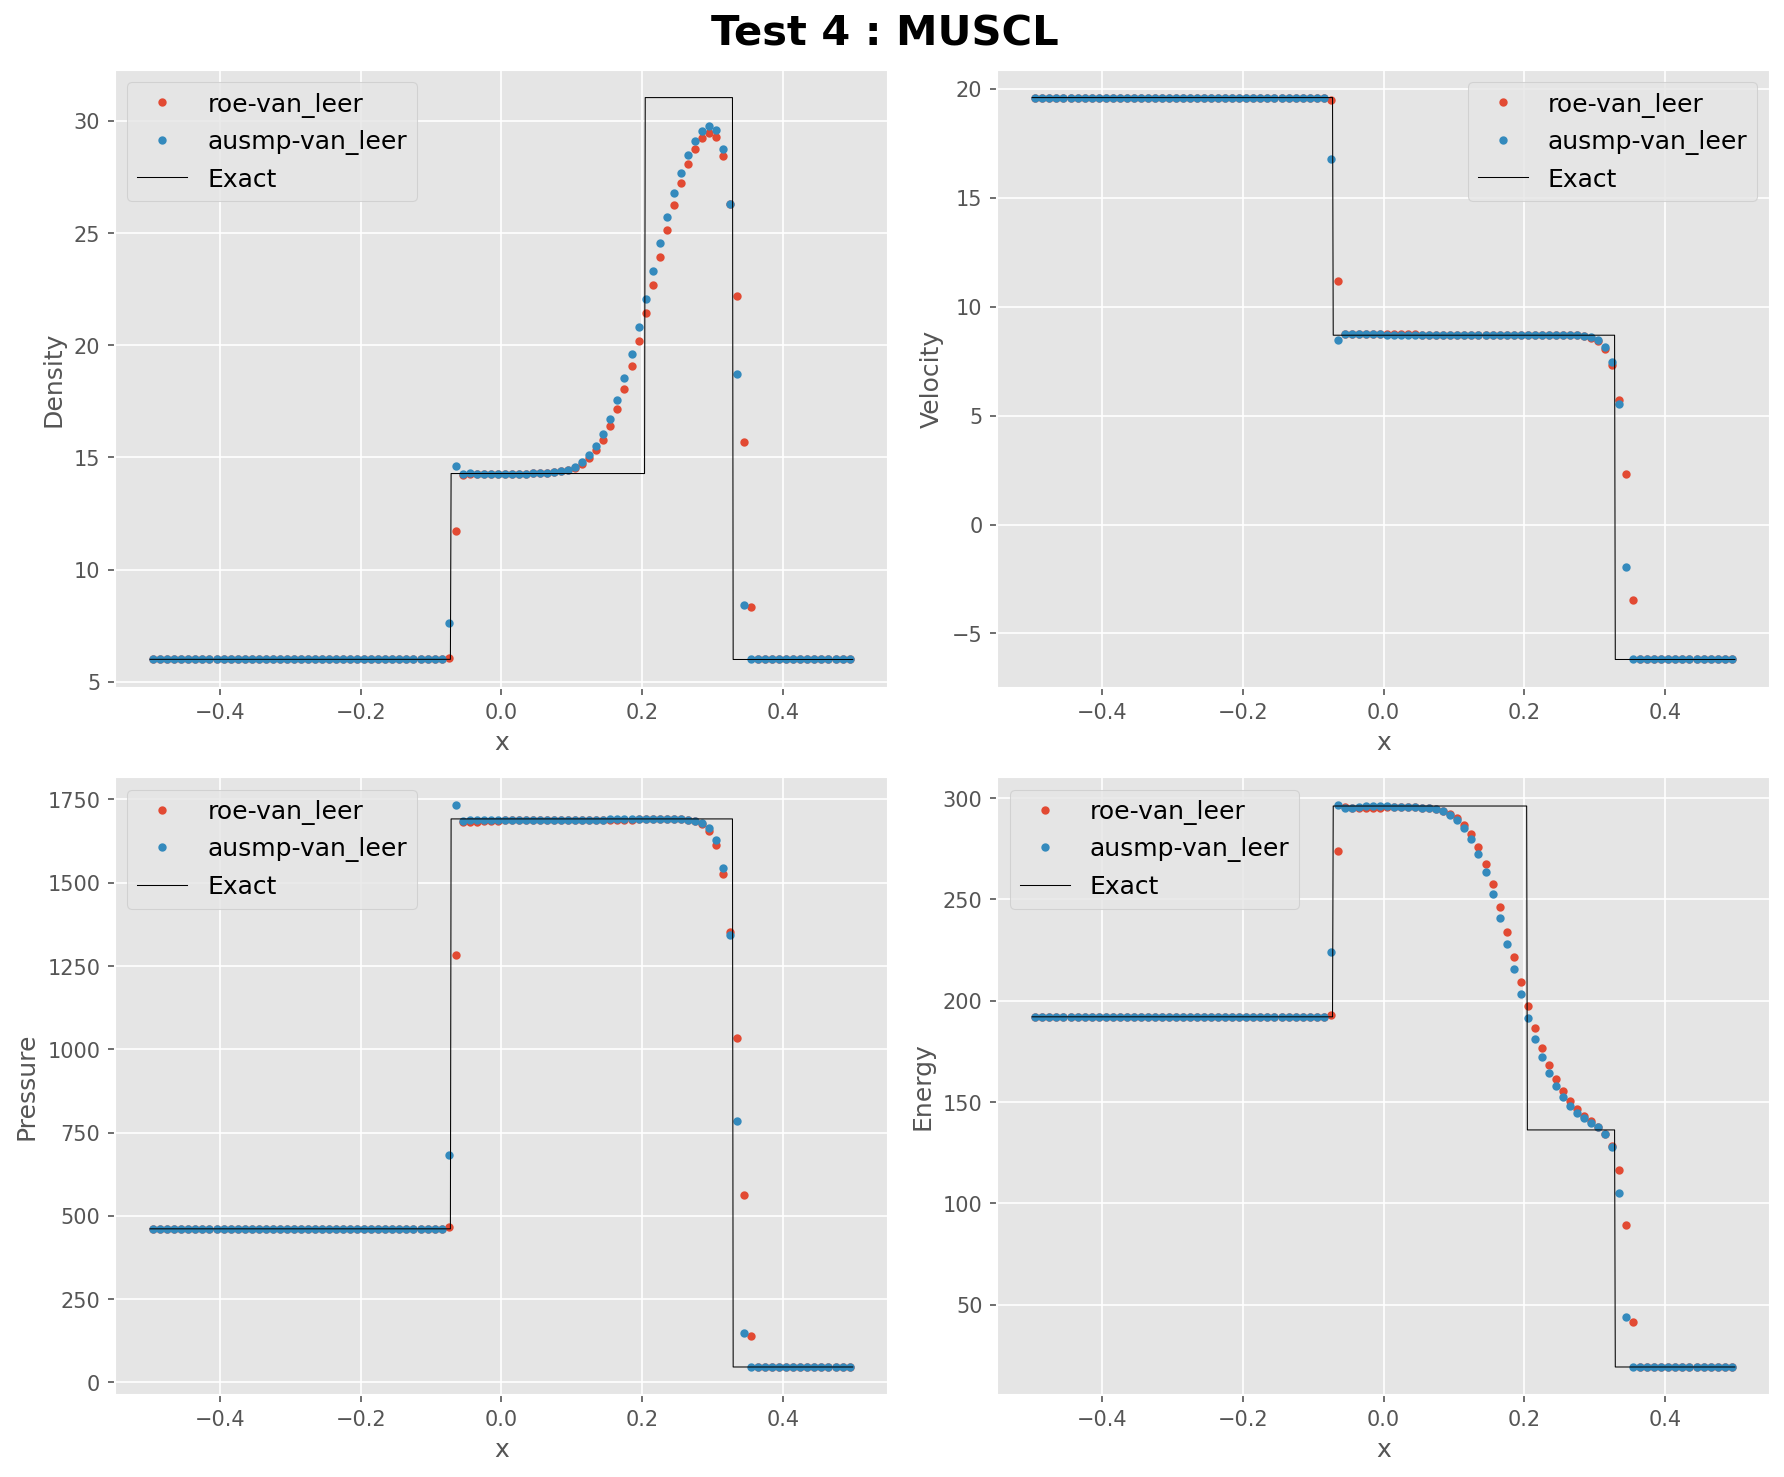

In [ ]:
flux_list = ['roe', 'ausmp']
limiter_list = ['van_leer']
# limiter_list = ['minmod', 'van_leer', 'superbee']

results40 = {}

# CFL 
cfl = 0.8
target_time = 0.035

for flux_name in flux_list:
    for limiter_name in limiter_list:
        key = f"{flux_name}-{limiter_name}"
        u = run_muscl_solver(flux_name, limiter_name, q4, xbk4)

        q = np.empty_like(u)
        to_primitive(u, q)

        results40[key] = q
        
plot_muscl_results(results40, xc, npad, gamma)

In [ ]:
def plot_muscl_results(results, xc, npad, gamma):
    vars_idx = {
        'Density': 0,
        'Velocity': 1,
        'Pressure': 2,
        'Energy': 3
    }

    plt.figure(figsize=(12, 10))
    x_e, rho_e, u_e, p_e = load_exact(5)
    e_e = exact_energy(rho_e, u_e, p_e, gamma)
    for i, (var, idx) in enumerate(vars_idx.items(), 1):
        plt.subplot(2, 2, i)

        for name, q in results.items():
            rho = q[0, npad:-npad]
            vel = q[1, npad:-npad]
            p   = q[2, npad:-npad]

            # Total Energy
            E = p/((gamma-1)*rho)

            if var == 'Energy':
                plt.plot(xc, E, marker='.', linestyle='None', label=name)
            else:
                plt.plot(xc, q[idx, npad:-npad], marker='.', linestyle='None', label=name)
        if var == 'Density':
            plt.plot(x_e, rho_e, 'k-', linewidth=0.5, label='Exact')
        elif var == 'Velocity':
            plt.plot(x_e, u_e, 'k-', linewidth=0.5, label='Exact')
        elif var == 'Pressure':
            plt.plot(x_e, p_e, 'k-', linewidth=0.5, label='Exact')
        elif var == 'Energy':
            plt.plot(x_e, e_e, 'k-', linewidth=0.5, label='Exact')
        plt.xlabel('x')
        plt.ylabel(var)
        plt.legend(fontsize=12)

    plt.suptitle('Test 5 : MUSCL ', fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()

#### Test 5 : Slowly-moving contact discontinuities
- AUSM+ : more accuracy but oscillation
- Roe : minmod 이상의 리미터 적용 시 불안정

Riemann Solver : roe
Minmod limiter


c:\Users\HaeunLee\Desktop\2026-1\CFD2\euler1d\test\solvers\timestep.py:40: RuntimeWarning: invalid value encountered in sqrt
  a = np.sqrt(gamma*p/rho)


roe-minmod: 107 iterations
Riemann Solver : ausmp
Minmod limiter
ausmp-minmod: 115 iterations


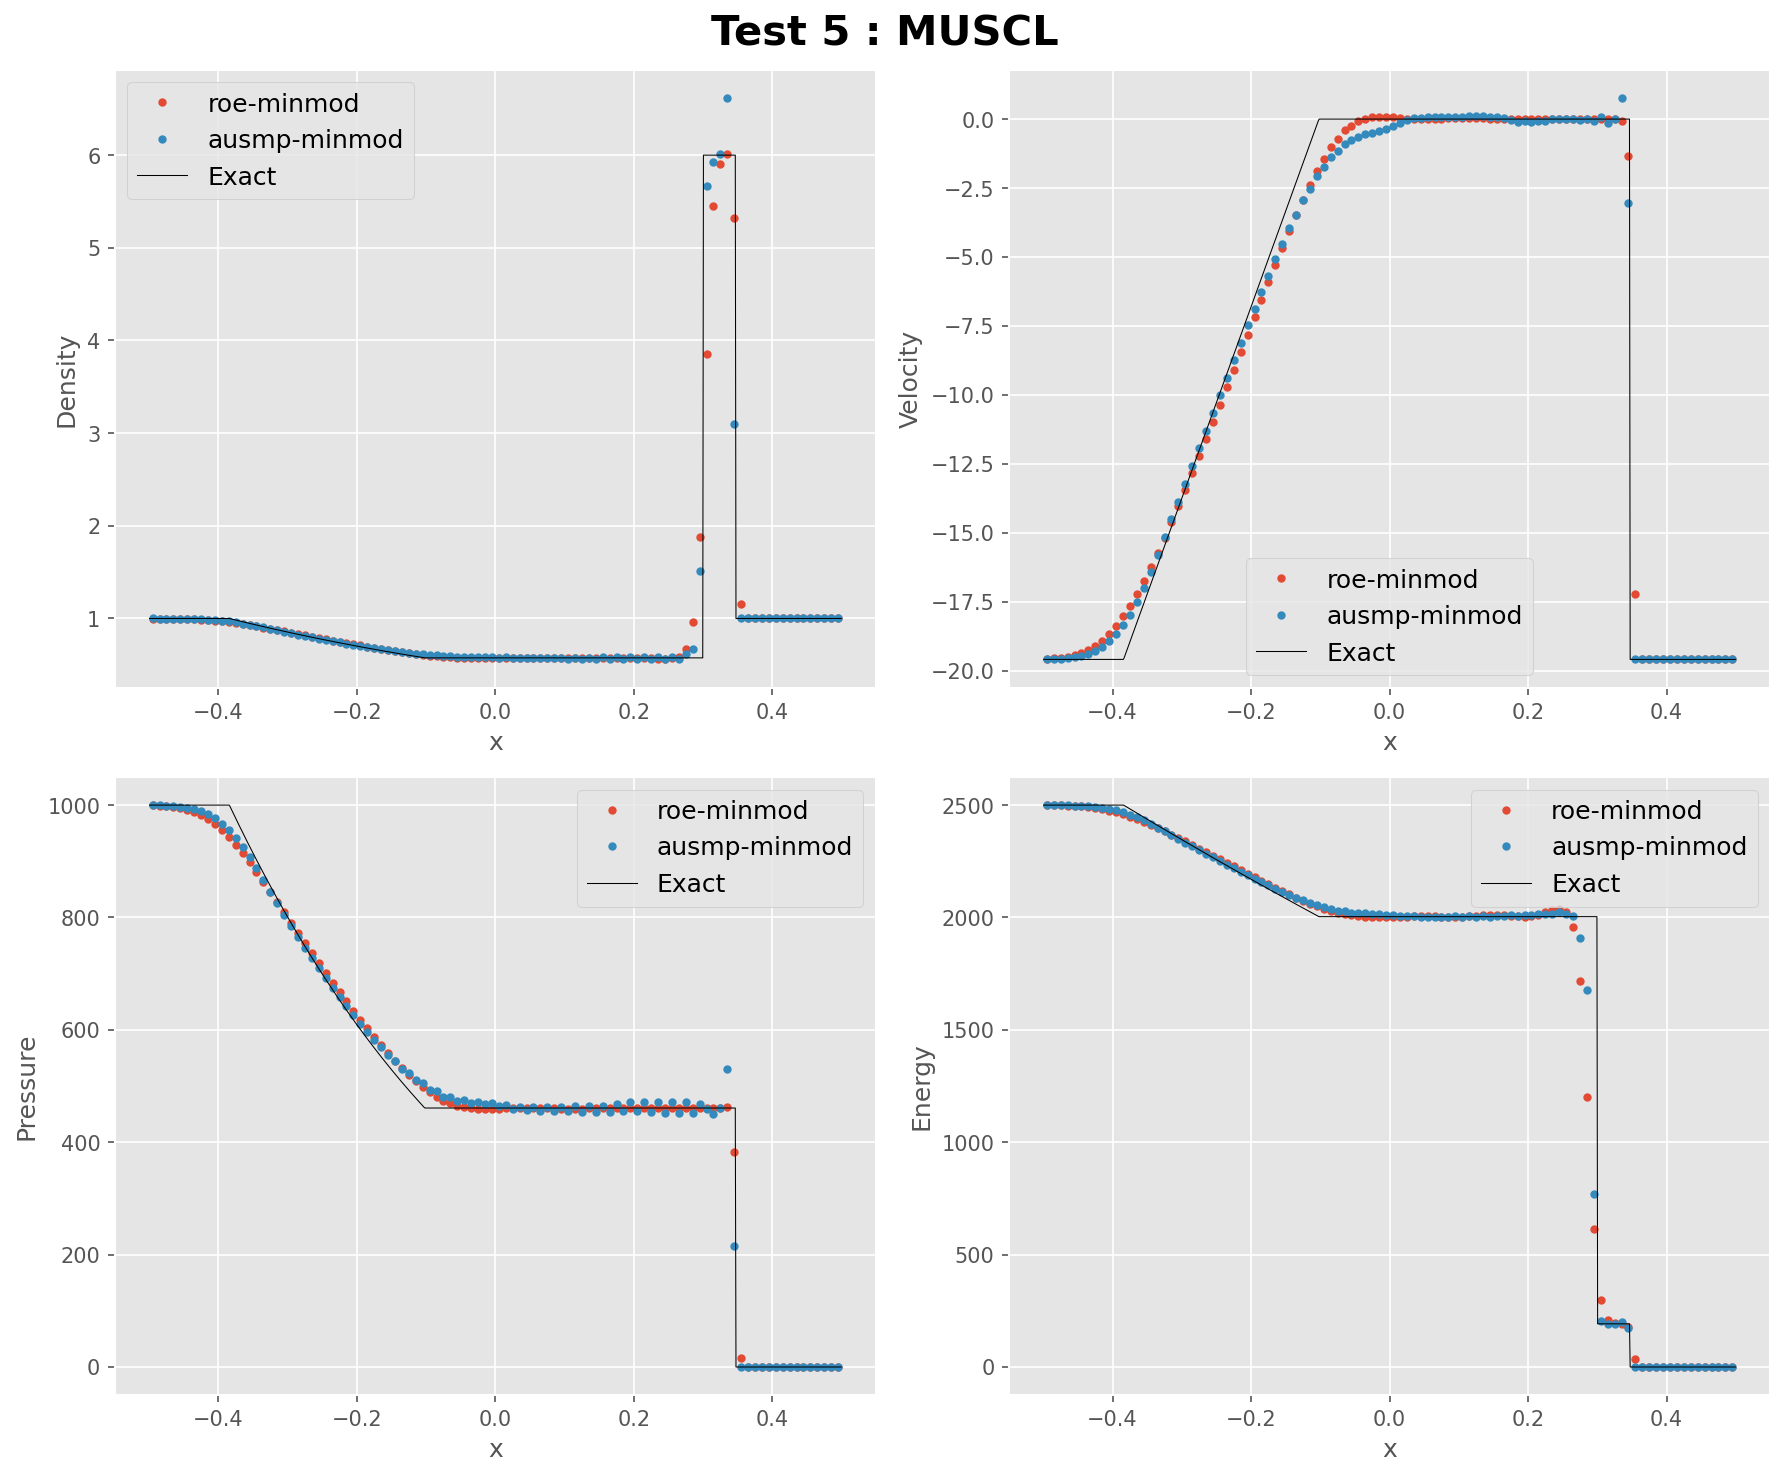

In [ ]:
flux_list = ['roe', 'ausmp']
limiter_list = ['minmod']
# limiter_list = ['minmod', 'van_leer', 'superbee']

results60 = {}

# CFL 
cfl = 0.6
target_time = 0.012

for flux_name in flux_list:
    for limiter_name in limiter_list:
        key = f"{flux_name}-{limiter_name}"
        u = run_muscl_solver(flux_name, limiter_name, q5, xbk5)

        q = np.empty_like(u)
        to_primitive(u, q)

        results60[key] = q
        
plot_muscl_results(results60, xc, npad, gamma)